[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_C_new_keynesian_local.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Frictions in Goods and Labor Markets: Sticky Prices, Monetary Non-Neutrality, and Search Frictions

**Why does monetary policy have real effects in the short run, and why is unemployment an equilibrium phenomenon rather than a residual?** The frictionless neoclassical and RBC benchmarks assume perfect price flexibility and instantaneous Walrasian market clearing. When these assumptions are confronted with empirical data, two profound anomalies emerge: monetary policy rate changes persistently alter real GDP (Christiano, Eichenbaum & Evans 2005), and unemployment coexists with unfilled vacancies across the business cycle (Beveridge 1944).

This notebook implements the complete pedagogical journey from **Slides 08**:
1. **The Canonical 3-Equation New Keynesian DSGE Model**: Dixit-Stiglitz monopolistic competition and Calvo (1983) pricing with Dynare AST diagnostics (`check`, `resid`, `model_diagnostics`).
2. **The Taylor Principle & Blanchard-Kahn Determinacy**: Evaluating $\phi_\pi > 1$ using Klein (2000) QZ flags.
3. **Monetary Policy Transmission**: Simulating a 25 bps contractionary policy shock and tracing non-neutrality.
4. **Central Bank Dilemmas**: Demand shocks (divine coincidence) vs. cost-push inflation shocks.
5. **Labor Search Frictions (Merz-Andolfatto)**: Loading `modelos/merz_andolfatto.mod`, Beveridge curve, and Shimer (2005) puzzle with full AST diagnostics.
6. **Interactive Experiment**: Average Inflation Targeting (AIT) vs. standard Taylor rules.
7. **The Determinacy Region in Two Dimensions**: Analytical Bullard-Mitra / Woodford frontier on the $(\phi_\pi, \phi_y)$ plane.
8. **The Taylor Curve**: The inflation-output volatility policy frontier.
9. **Calvo Stickiness**: Deriving the microfoundations of $\kappa$, Frisch elasticity, and the flexible-price neutrality limit.
10. **The Shimer Puzzle Measured**: Measuring amplification ratios and Beveridge dynamics on simulated data.
11. **Two-Sided Kalman Smoothing & Shock Decomposition**: Historical state reconstruction ($\mathbb{E}[x_t \mid \mathcal{Y}_T]$ vs $\mathbb{E}[x_t \mid \mathcal{Y}_t]$) and structural post-COVID inflation decomposition.
12. **Dynamic DSGE Forecasting**: Model-consistent forward fan charts with 90% confidence bands.
13. **Non-Linear DSGE Simulation via Extended Path**: Fair & Taylor (1983) non-linear boundary value simulation, verifying linear invariance to machine precision and enforcing policy floors via mixed complementarity (MCP).

In [2]:
# ==============================================================================
# Model Loading & Baseline Solution with load_mod
# ==============================================================================
from puremacro.dsge import load_mod

# Resolve model path
from _datos import ruta_dato, ruta_modelo

# Resolve model path
nk_mod_path = ruta_modelo("new_keynesian_3eq.mod")

m_nk = load_mod(nk_mod_path)

print(f"Canonical New Keynesian Model loaded: {nk_mod_path}")
print(f"Predetermined States (x_t) : {m_nk.states}")
print(f"Forward Controls     (y_t) : {m_nk.controls}")
print(f"Structural Innovations (u_t): {m_nk.shocks}")

# Display Decision Rules
dr_nk = m_nk.decision_rules().to_frame()
print("\nPOLICY AND TRANSITION FUNCTIONS (Dynare Format):")
print(dr_nk.round(6))

# Blanchard-Kahn Determinacy Check
eu_baseline = m_nk.solution.eu
print(f"\nBlanchard-Kahn Status (Existence, Uniqueness): {eu_baseline}")
assert eu_baseline == (1, 1), "Baseline model must have a unique stable rational expectations equilibrium."

# Comprehensive Model Diagnostics (resid, check, model_diagnostics)
res_nk = m_nk.resid()
check_nk = m_nk.check()
diag_nk = m_nk.model_diagnostics()

print("\n" + "=" * 76)
print("STRUCTURAL MODEL DIAGNOSTICS & EIGENVALUE SPECTRUM")
print("=" * 76)
print(f"Maximum Steady-State Residual     : {res_nk.abs().max():.2e}")
print(f"Blanchard-Kahn Determinacy Status : {check_nk.bk_status}")
print(f"Diagnostics Overall Result        : {'PASSED' if diag_nk.passed else 'FAILED'} (Rank: {diag_nk.static_rank}/{diag_nk.static_n_vars})")
print("=" * 76)
print("\n" + check_nk.summary())
print("\n" + diag_nk.summary())

assert res_nk.abs().max() < 1e-10, "Steady state residual failure!"
assert check_nk.is_determinate is True, "Blanchard-Kahn determinacy failure!"
assert diag_nk.passed is True, "Structural diagnostics failure!"

Canonical New Keynesian Model loaded: modelos/new_keynesian_3eq.mod
Predetermined States (x_t) : ('i', 'rn', 'u')
Forward Controls     (y_t) : ('y_gap', 'pi')
Structural Innovations (u_t): ('eps_i', 'eps_rn', 'eps_u')

POLICY AND TRANSITION FUNCTIONS (Dynare Format):
             y_gap        pi         i   rn    u
Constant  0.000000  0.000000  0.000000  0.0  0.0
i(-1)    -1.643529 -0.443149  0.532459  0.0  0.0
rn(-1)    0.706009  0.119992  0.067060  0.5  0.0
u(-1)    -0.693339  0.628966  0.214196  0.0  0.5
eps_i    -2.191372 -0.590865  0.709945  0.0  0.0
eps_rn    1.412017  0.239984  0.134119  1.0  0.0
eps_u    -1.386678  1.257933  0.428391  0.0  1.0

Blanchard-Kahn Status (Existence, Uniqueness): (1, 1)

STRUCTURAL MODEL DIAGNOSTICS & EIGENVALUE SPECTRUM
Maximum Steady-State Residual     : 0.00e+00
Blanchard-Kahn Determinacy Status : Blanchard-Kahn condition satisfied: 5 explosive roots for 5 forward-looking variables (unique stable equilibrium).
Diagnostics Overall Result        : P

## The Taylor Principle & Blanchard-Kahn Determinacy Frontier

A foundational result in monetary macroeconomics (**Slides 08, Slide 140-150**) is the **Taylor Principle** (Taylor 1993, Clarida, Galí & Gertler 1999, Woodford 2003):
$$ \phi_\pi > 1 $$

### The Economic Mechanism:
- When inflation rises by $1\%$, the nominal interest rate must increase by **more than $1\%$** ($\phi_\pi > 1$) so that the **real interest rate** $r_t = i_t - E_t \pi_{t+1}$ rises. A higher real interest rate depresses aggregate demand through the dynamic IS curve, cooling the economy and restoring price stability.
- If monetary policy is passive ($\phi_\pi \le 1$), a rise in expected inflation reduces the real interest rate, stimulating demand and confirming higher inflation in a self-fulfilling spiral.

In the Klein (2000) QZ solver, this condition maps directly into the **Blanchard-Kahn rank condition**:
- The number of finite generalized eigenvalues outside the unit circle must exactly match the number of forward-looking jump variables ($n_{\text{fwd}} = 2$: $\tilde{y}_t$ and $\pi_t$). The table's count also includes three infinite roots, one from each equation without a lead (the Taylor rule and the two AR(1) shocks), so a determinate rule shows $5$ unstable roots and an indeterminate one $4$.
- When the long-run response $\phi_\pi + \frac{1-\beta}{\kappa}\phi_y$ falls below $1$ — with $\phi_y = 0.125$, when $\phi_\pi$ is below about $0.99$ — too few eigenvalues are unstable, leading to **indeterminacy** (`eu == (1, 0)`) and sunspot fluctuations.

In [3]:
# ==============================================================================
# Taylor Principle Parameter Sweep over phi_pi
# ==============================================================================
phi_pi_sweep = [0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.5, 2.0]
sweep_records = []

for p_pi in phi_pi_sweep:
    # strict=False so an indeterminate rule returns its Blanchard-Kahn flags
    # instead of raising: observing indeterminacy is the point of this sweep.
    m_temp = load_mod(nk_mod_path, params={"phi_pi": p_pi}, strict=False)
    eu_flag = m_temp.solution.eu
    
    # Count stable eigenvalues
    n_stable = int(np.sum(np.abs(m_temp.eigenvalues) < 1.0))
    n_unstable = len(m_temp.eigenvalues) - n_stable
    
    # eu = (existence, uniqueness): (1, 0) is indeterminacy, (0, 0) no stable solution.
    if eu_flag == (1, 1):
        regime = "Determinate (Unique Saddle Path)"
    elif eu_flag == (1, 0):
        regime = "Indeterminate (Sunspot Fluctuations)"
    else:
        regime = "No Stable Equilibrium (Explosive)"
        
    sweep_records.append({
        "phi_pi": p_pi,
        "eu_flags": str(eu_flag),
        "Stable Eig": n_stable,
        "Unstable Eig (Jumps)": n_unstable,
        "Regime": regime,
    })

sweep_taylor_df = pd.DataFrame(sweep_records)
print("TAYLOR PRINCIPLE & BLANCHARD-KAHN DETERMINACY FRONTIER:")
print(sweep_taylor_df.to_string(index=False))

# Assertions
assert sweep_taylor_df.loc[sweep_taylor_df["phi_pi"] == 0.5, "eu_flags"].values[0] == "(1, 0)"
assert sweep_taylor_df.loc[sweep_taylor_df["phi_pi"] == 1.5, "eu_flags"].values[0] == "(1, 1)"
# Long-run Taylor principle: determinate iff phi_pi + (1 - beta) * phi_y / kappa > 1
cal_nk = m_nk._params
phi_pi_star = 1.0 - (1.0 - cal_nk["beta"]) * cal_nk["phi_y"] / cal_nk["kappa"]
assert all((r["eu_flags"] == "(1, 1)") == (r["phi_pi"] > phi_pi_star) for r in sweep_records)
print(f"\nTaylor Principle verification: with phi_y = {cal_nk['phi_y']:.3f}, phi_pi < {phi_pi_star:.3f} "
      f"(long-run response below 1) triggers indeterminacy, phi_pi > {phi_pi_star:.3f} guarantees uniqueness.")

TAYLOR PRINCIPLE & BLANCHARD-KAHN DETERMINACY FRONTIER:
 phi_pi eu_flags  Stable Eig  Unstable Eig (Jumps)                               Regime
    0.5   (1, 0)           4                     4 Indeterminate (Sunspot Fluctuations)
    0.7   (1, 0)           4                     4 Indeterminate (Sunspot Fluctuations)
    0.9   (1, 0)           4                     4 Indeterminate (Sunspot Fluctuations)
    1.0   (1, 1)           3                     5     Determinate (Unique Saddle Path)
    1.1   (1, 1)           3                     5     Determinate (Unique Saddle Path)
    1.3   (1, 1)           3                     5     Determinate (Unique Saddle Path)
    1.5   (1, 1)           3                     5     Determinate (Unique Saddle Path)
    2.0   (1, 1)           3                     5     Determinate (Unique Saddle Path)

Taylor Principle verification: with phi_y = 0.125, phi_pi < 0.990 (long-run response below 1) triggers indeterminacy, phi_pi > 0.990 guarantees uniquen

## Monetary Policy Transmission: Non-Neutrality of Money

Slide 150 of `Slides08mav.tex` illustrates the transmission mechanism of a monetary policy tightening. In the neoclassical model, changes in nominal variables leave real allocations untouched (money is neutral). In the New Keynesian model with Calvo price stickiness, money is **non-neutral**:

1. **Policy Innovation**: The central bank raises the policy rate by 25 basis points ($\varepsilon_{i,t} = +0.0025$).
2. **Real Rate Spike**: Because only a fraction $(1-\theta)$ of firms can adjust prices in any period, expected inflation cannot adjust immediately. The real interest rate $r_t = i_t - E_t \pi_{t+1}$ jumps upward.
3. **Aggregate Demand Contraction**: Forward-looking consumers postpone consumption along the dynamic IS curve. The output gap turns negative ($\tilde{y}_t < 0$).
4. **Disinflation**: Firms with reset opportunities observe sluggish demand and lower marginal costs, leading them to set lower prices. Inflation decelerates ($\pi_t < 0$).

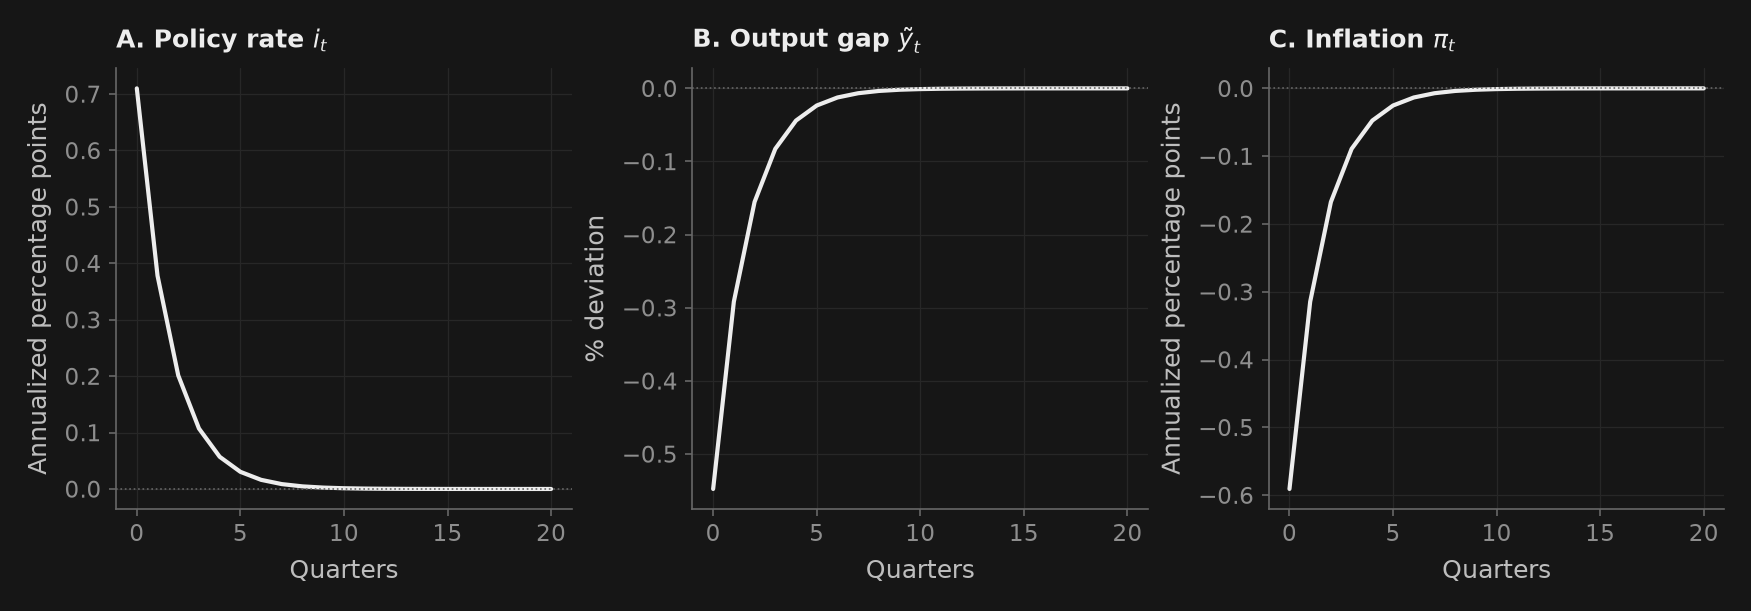

Impact Output Gap: -0.548% | Impact Inflation: -0.591 bps


In [4]:
# Extract 20-period impulse response functions for a 25 bps rate hike
irf_mon = m_nk.irf("eps_i", horizon=20, size=0.0025)

fig, axes = _nbstyle.figura(1, 3)

# 1. Nominal Policy Rate
axes[0].plot(irf_mon.index, irf_mon["i"] * 400, **_nbstyle.S1)
axes[0].axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
axes[0].set_title("A. Policy rate $i_t$")
axes[0].set_xlabel("Quarters")
axes[0].set_ylabel("Annualized percentage points")

# 2. Output Gap
axes[1].plot(irf_mon.index, irf_mon["y_gap"] * 100, **_nbstyle.S1)
axes[1].axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
axes[1].set_title("B. Output gap $\\tilde{y}_t$")
axes[1].set_xlabel("Quarters")
axes[1].set_ylabel("% deviation")

# 3. Inflation
axes[2].plot(irf_mon.index, irf_mon["pi"] * 400, **_nbstyle.S1)
axes[2].axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
axes[2].set_title("C. Inflation $\\pi_t$")
axes[2].set_xlabel("Quarters")
axes[2].set_ylabel("Annualized percentage points")

plt.show()

# Assertions
assert irf_mon.loc[0, "y_gap"] < 0, "Monetary contraction must depress output gap."
assert irf_mon.loc[0, "pi"] < 0, "Monetary contraction must reduce inflation."
print(f"Impact Output Gap: {irf_mon.loc[0, 'y_gap']*100:.3f}% | Impact Inflation: {irf_mon.loc[0, 'pi']*400:.3f} bps")


## Central Bank Dilemmas: Demand Shocks vs. Cost-Push Inflation Shocks

Slides 170–190 of `Slides08mav.tex` contrast two distinct shock types that central banks encounter:
- **Demand / Natural Rate Shocks ($r_t^n$)**: Consumer sentiment or fiscal spending shifts the dynamic IS curve. Under demand shocks, the **"Divine Coincidence"** (Blanchard & Galí 2007) holds: stabilizing inflation simultaneously eliminates the output gap ($\pi_t = 0 \iff \tilde{y}_t = 0$). There is no policy trade-off.
- **Cost-Push / Supply Shocks ($u_t$)**: Supply chain bottlenecks, commodity spikes, or markup fluctuations shift the NKPC directly. The divine coincidence breaks down:
  - Hikes to suppress inflation deepen the recession ($\tilde{y} < 0$).
  - Accommodation to protect jobs allows inflation to become entrenched.
  - This was precisely the dilemma faced by the Federal Reserve, Banxico, and the ECB during the **2021–2023 inflation spike**.

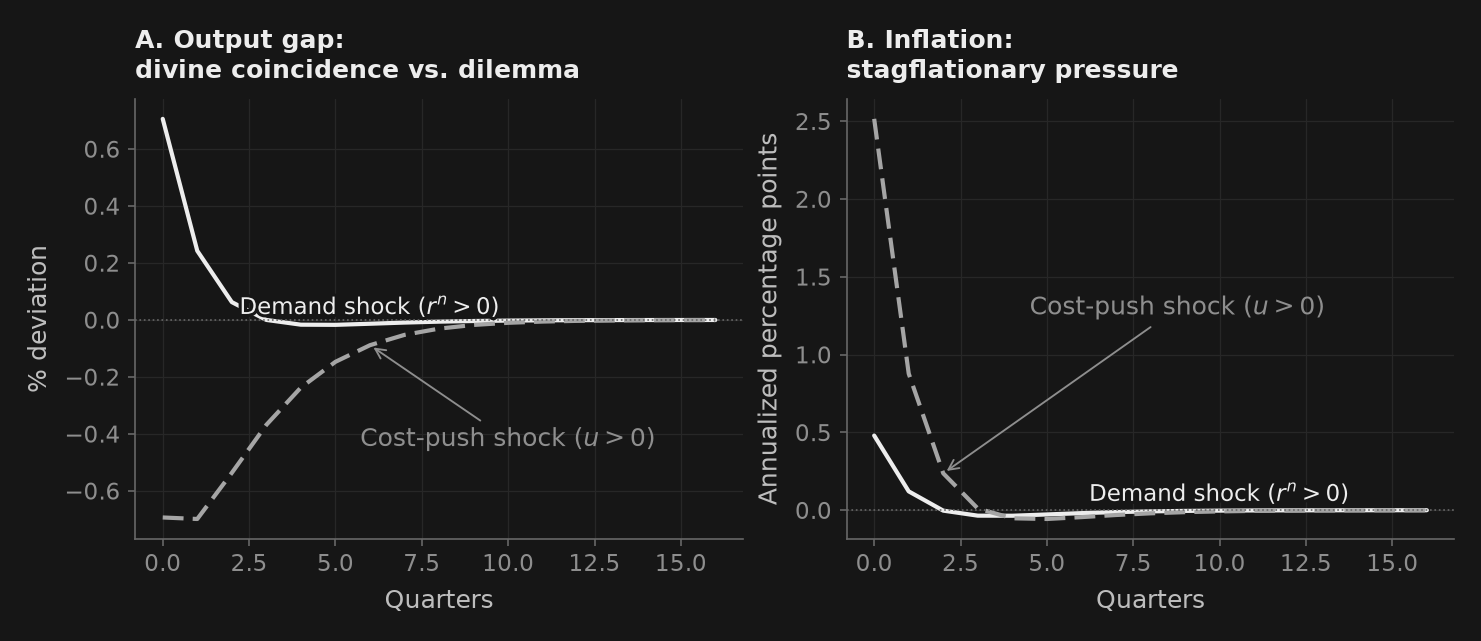

In [5]:
# Compare 50 bps Demand Shock (eps_rn) vs. 50 bps Cost-Push Shock (eps_u)
irf_demand = m_nk.irf("eps_rn", horizon=16, size=0.005)
irf_supply = m_nk.irf("eps_u",  horizon=16, size=0.005)

fig, (ax_d_y, ax_d_pi) = _nbstyle.figura(1, 2)

# Output Gap Comparison
ax_d_y.plot(irf_demand.index, irf_demand["y_gap"] * 100, **_nbstyle.S1, label="Demand shock ($r^n > 0$)")
ax_d_y.plot(irf_supply.index, irf_supply["y_gap"] * 100, **_nbstyle.S2)
ax_d_y.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_d_y.set_title("A. Output gap:\ndivine coincidence vs. dilemma")
ax_d_y.set_xlabel("Quarters")
ax_d_y.set_ylabel("% deviation")
ax_d_y.annotate("Cost-push shock ($u > 0$)", xy=(6.0, float(irf_supply.loc[6, "y_gap"] * 100)), xytext=(10.0, -0.42),
                ha="center", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
_nbstyle.etiquetar(ax_d_y, donde=6.0)

# Inflation Comparison
ax_d_pi.plot(irf_demand.index, irf_demand["pi"] * 400, **_nbstyle.S1, label="Demand shock ($r^n > 0$)")
ax_d_pi.plot(irf_supply.index, irf_supply["pi"] * 400, **_nbstyle.S2)
ax_d_pi.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_d_pi.set_title("B. Inflation:\nstagflationary pressure")
ax_d_pi.set_xlabel("Quarters")
ax_d_pi.set_ylabel("Annualized percentage points")
ax_d_pi.annotate("Cost-push shock ($u > 0$)", xy=(2.0, float(irf_supply.loc[2, "pi"] * 400)), xytext=(4.5, 1.3),
                 ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
_nbstyle.etiquetar(ax_d_pi, donde=10.0)

plt.show()


## Labor Market Search Frictions: Merz-Andolfatto (`modelos/merz_andolfatto.mod`)

Section 2 of `Slides08mav.tex` (Láminas 860-900 y 1459) extends the frictionless model to incorporate search and matching in labor markets (Diamond 1982, Mortensen & Pissarides 1994, Merz 1995, Andolfatto 1996).

### Key Structural Features:
1. **Matching Function**: $m_t = \bar{m} u_t^\sigma v_t^{1-\sigma}$, matching job searchers $u_t$ and vacancies $v_t$.
2. **Labor Market Tightness**: $\theta_t = v_t / u_t$. When tightness rises, firms find workers more slowly, but job searchers find jobs faster.
3. **The Beveridge Curve**: Equilibrium generating a negative empirical relationship between unemployment and vacancies. Mind *which* unemployment: the model carries `u_head` $= 1 - n_{t-1}$, unemployment by heads, and also `urate`, which weights the non-employed by search intensity $x_t$. Because $x_t$ is procyclical, `urate` is nearly acyclical and traces an **upward**-sloping locus — an artefact of the weighting, not an economic finding. The Beveridge curve is always drawn with `u_head`; Section 10 puts the two side by side.
4. **The Shimer (2005) Volatility Puzzle**: In standard Nash wage bargaining, wages absorb nearly all cyclical productivity gains. Consequently, the incentive to post vacancies varies insufficiently, yielding $\sigma(\theta) / \sigma(A)$ far smaller than observed in data.

We solve `modelos/merz_andolfatto.mod` directly with `puremacro.dsge.load_mod`.

Merz-Andolfatto Model loaded: modelos/merz_andolfatto.mod
States   : ('k', 'n', 'a')
Controls : 17 endogenous variables: ('c', 'x', 'l', 'v', 'lam', 'mum', 'y', 'm')...


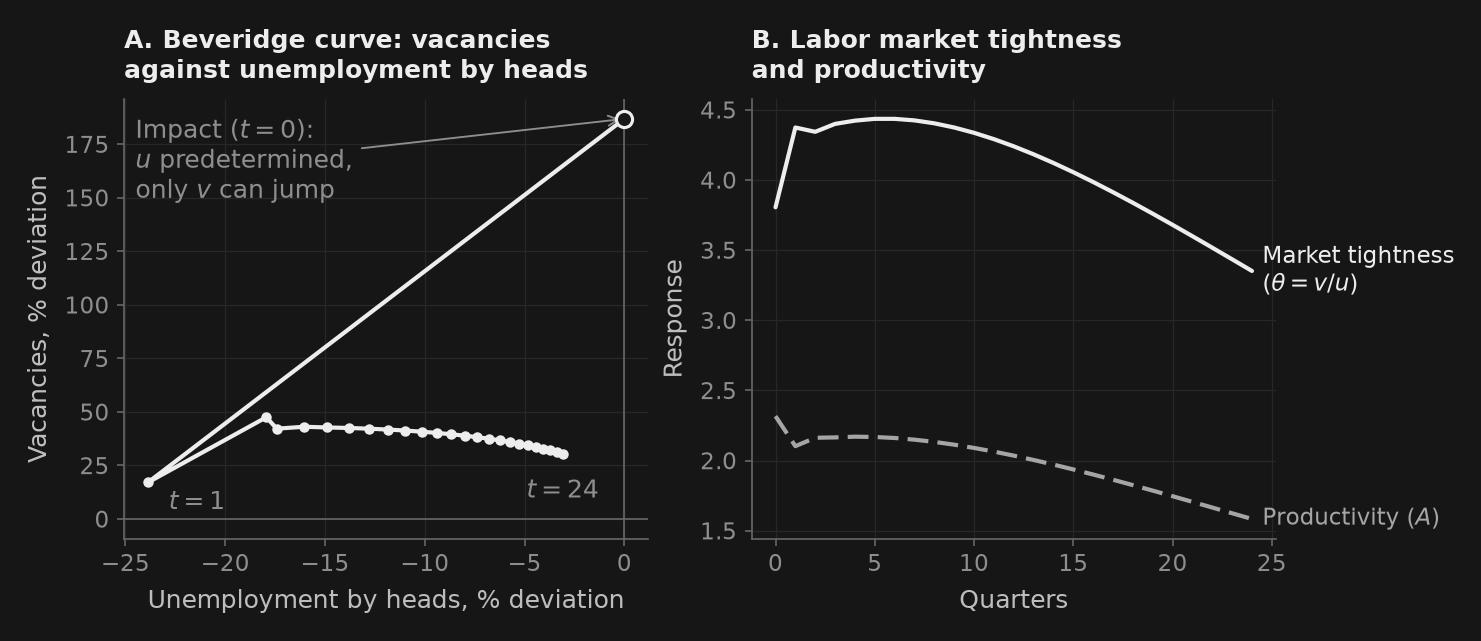

Impact Labor Market Tightness Amplification theta/A: 2.08x

Merz-Andolfatto Steady-State Residual : 8.96e-10
Merz-Andolfatto Blanchard-Kahn Status  : Blanchard-Kahn condition satisfied: 20 explosive roots for 20 forward-looking variables (unique stable equilibrium).
Merz-Andolfatto Diagnostics Passed     : True (Rank: 20/20)


In [6]:
# Load and solve the actual course Merz-Andolfatto model
ma_mod_path = ruta_modelo("merz_andolfatto.mod")

# Harmless: puremacro's steady-state solver probes the call signature with every variable at 1, which divides by zero in this model's equations; that value is discarded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar divide", category=RuntimeWarning)
    m_ma = load_mod(ma_mod_path)

print(f"Merz-Andolfatto Model loaded: {ma_mod_path}")
print(f"States   : {m_ma.states}")
print(f"Controls : {len(m_ma.controls)} endogenous variables: {m_ma.controls[:8]}...")

# 20-period IRF to a 1% technology shock
irf_ma = m_ma.irf("e_a", horizon=24, size=1.0)

fig, (ax_bev, ax_theta) = _nbstyle.figura(1, 2)

# Panel 1: Beveridge Curve Phase Trajectory (Vacancies vs. Unemployment by heads).
# u_head = 1 - n(-1) is the model's unemployment; `urate` is search-intensity weighted and
# would put this trajectory in the wrong quadrant (see the note above and Section 10).
ss_ma_levels = {n: float(v) for n, v in zip(m_ma.variables, m_ma.decision_rules().to_frame().loc["Constant"])}
u_bev = 100.0 * irf_ma["u_head"] / ss_ma_levels["u_head"]
v_bev = 100.0 * irf_ma["v"] / ss_ma_levels["v"]
ax_bev.plot(u_bev, v_bev, **_nbstyle.S1, marker="o", markersize=4)
ax_bev.scatter([u_bev.iloc[0]], [v_bev.iloc[0]], s=60, zorder=5, facecolors=_nbstyle.FONDO,
               edgecolors=_nbstyle.TINTA, linewidths=1.5)
ax_bev.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_bev.axvline(0, color=_nbstyle.SPINE, lw=0.8)
ax_bev.set_title("A. Beveridge curve: vacancies\nagainst unemployment by heads")
ax_bev.set_xlabel("Unemployment by heads, % deviation")
ax_bev.set_ylabel("Vacancies, % deviation")
ax_bev.annotate("Impact ($t = 0$):\n$u$ predetermined,\nonly $v$ can jump",
                xy=(0.0, float(v_bev.iloc[0])), xytext=(-24.5, 188.0), ha="left", va="top",
                color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_bev.annotate("$t = 1$", xy=(float(u_bev.iloc[1]), float(v_bev.iloc[1])), xytext=(10, -4),
                textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA)
ax_bev.annotate("$t = 24$", xy=(float(u_bev.iloc[-1]), float(v_bev.iloc[-1])), xytext=(0, -12),
                textcoords="offset points", ha="center", va="top", color=_nbstyle.NOTA)

# The whole transition after impact must sit in the Beveridge quadrant: u down, v up
assert (u_bev.iloc[1:] < 0).all() and (v_bev.iloc[1:] > 0).all(), (
    "A positive technology shock must lower unemployment and raise vacancies."
)

# Panel 2: Market Tightness & The Shimer Puzzle
ax_theta.plot(irf_ma.index, irf_ma["theta"], **_nbstyle.S1, label="Market tightness\n($\\theta = v/u$)")
ax_theta.plot(irf_ma.index, irf_ma["prod"], **_nbstyle.S2, label="Productivity ($A$)")
ax_theta.set_title("B. Labor market tightness\nand productivity")
ax_theta.set_xlabel("Quarters")
ax_theta.set_ylabel("Response")
_nbstyle.etiquetar(ax_theta, donde="fin")

plt.show()

# Shimer Volatility Ratio
shimer_ratio = irf_ma.loc[1, "theta"] / irf_ma.loc[1, "prod"]
print(f"Impact Labor Market Tightness Amplification theta/A: {shimer_ratio:.2f}x")

# Run Dynare AST model diagnostics on Merz-Andolfatto labor search model
res_ma = m_ma.resid()
check_ma = m_ma.check()
diag_ma = m_ma.model_diagnostics()

print(f"\nMerz-Andolfatto Steady-State Residual : {res_ma.abs().max():.2e}")
print(f"Merz-Andolfatto Blanchard-Kahn Status  : {check_ma.bk_status}")
print(f"Merz-Andolfatto Diagnostics Passed     : {diag_ma.passed} (Rank: {diag_ma.static_rank}/{diag_ma.static_n_vars})")

assert res_ma.abs().max() < 1e-9, "Merz-Andolfatto steady state residual failure!"
assert check_ma.is_determinate is True, "Merz-Andolfatto determinacy failure!"
assert diag_ma.passed is True, "Merz-Andolfatto structural diagnostics failure!"


## Interactive Macro Experiment: Average Inflation Targeting (AIT) vs. Standard Taylor Rule

**The Economic Scenario**: In August 2020, the Federal Reserve adopted an Average Inflation Targeting (AIT) framework, pledging to seek inflation moderately above $2\%$ following periods of persistent shortfalls. In an environment with supply chain disruptions and cost-push shocks, how does history-dependent AIT perform relative to the standard contemporaneous Taylor rule?

**Model Formulation**:
- **Standard Rule**: $i_t = \rho_i i_{t-1} + (1-\rho_i)[\phi_\pi \pi_t + \phi_y \tilde{y}_t] + \varepsilon_{i,t}$
- **Average Inflation Targeting (AIT)**: The central bank responds to average inflation over the past two quarters:
  $$ i_t = \rho_i i_{t-1} + (1-\rho_i)\left[\phi_\pi \frac{\pi_t + \pi_{t-1}}{2} + \phi_y \tilde{y}_t\right] + \varepsilon_{i,t} $$

Execute the experiment below to test how AIT alters the policy tradeoff under a $+0.50\%$ cost-push inflation shock ($u_t$).

puremacro/dsge/_parser.py:1952: UserWarning: parse_mod: the shocks; block declares no variance for ['eps_i', 'eps_rn'] — following Dynare (M_.Sigma_e starts at zero), their innovation variance is 0, so they are inert in the moments, the IRFs and the second-order risk correction ghs2. Add 'var <name>; stderr <value>;' to the shocks; block if that is not what you meant.
  return parser.parse()


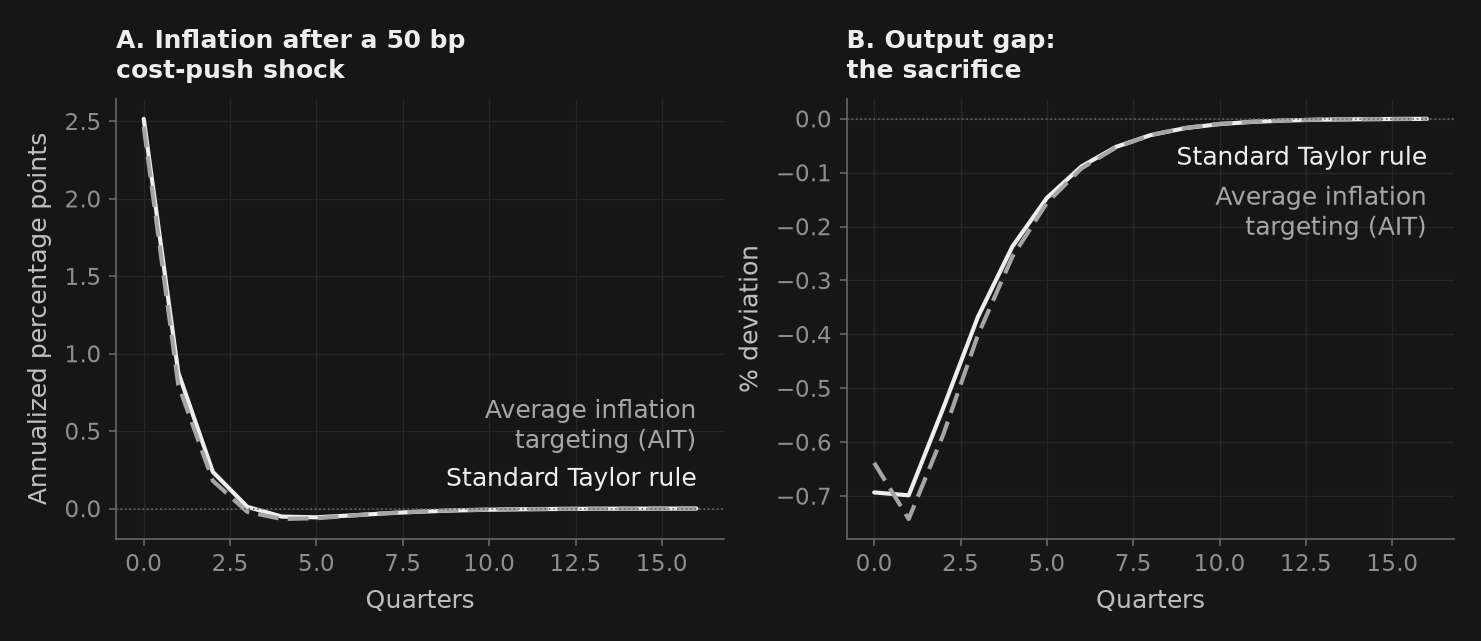

Standard Taylor Rule Peak Inflation: 2.52 bps
AIT Framework Peak Inflation       : 2.47 bps
All interactive policy framework experiment assertions passed successfully!


In [7]:
# ==============================================================================
# Interactive AIT Experiment: Standard Taylor Rule vs. Average Inflation Targeting
# ==============================================================================
mod_ait_spec = """
var y_gap pi i rn u pi_lag1;
varexo eps_i eps_rn eps_u;

parameters beta sigma kappa phi_pi phi_y rho_i rho_rn rho_u;
beta   = 0.99;
sigma  = 1.0;
kappa  = 0.1275;
phi_pi = 1.5;
phi_y  = 0.125;
rho_i  = 0.75;
rho_rn = 0.50;
rho_u  = 0.50;

model;
y_gap = y_gap(+1) - (1/sigma) * (i - pi(+1) - rn);
pi = beta * pi(+1) + kappa * y_gap + u;
pi_lag1 = pi(-1);
// Central bank targets average inflation over 2 quarters: 0.5 * (pi + pi_lag1)
i = rho_i * i(-1) + (1 - rho_i) * (phi_pi * 0.5 * (pi + pi_lag1) + phi_y * y_gap) + eps_i;
rn = rho_rn * rn(-1) + eps_rn;
u = rho_u * u(-1) + eps_u;
end;

initval;
y_gap = 0.0;
pi = 0.0;
i = 0.0;
rn = 0.0;
u = 0.0;
pi_lag1 = 0.0;
end;

shocks;
var eps_u; stderr 0.0050;
end;
"""

m_ait = load_mod(mod_ait_spec)
irf_std_u = m_nk.irf("eps_u", horizon=16, size=0.005)
irf_ait_u = m_ait.irf("eps_u", horizon=16, size=0.005)

fig, (ax_exp_pi, ax_exp_y) = _nbstyle.figura(1, 2)

# Inflation Path Comparison
ax_exp_pi.plot(irf_std_u.index, irf_std_u["pi"] * 400, **_nbstyle.S1, label="Standard Taylor rule")
ax_exp_pi.plot(irf_ait_u.index, irf_ait_u["pi"] * 400, **_nbstyle.S2, label="Average inflation\ntargeting (AIT)")
ax_exp_pi.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_exp_pi.set_title("A. Inflation after a 50 bp\ncost-push shock")
ax_exp_pi.set_xlabel("Quarters")
ax_exp_pi.set_ylabel("Annualized percentage points")
# The two paths almost coincide: the names stack next to their common endpoint
for k, ln in enumerate(ax_exp_pi.get_lines()[:2]):
    ax_exp_pi.annotate(ln.get_label(), xy=(16, 0.0), xytext=(0, 8 + 17 * k), textcoords="offset points",
                       ha="right", va="bottom", color=ln.get_color())

# Output Gap Comparison
ax_exp_y.plot(irf_std_u.index, irf_std_u["y_gap"] * 100, **_nbstyle.S1, label="Standard Taylor rule")
ax_exp_y.plot(irf_ait_u.index, irf_ait_u["y_gap"] * 100, **_nbstyle.S2, label="Average inflation\ntargeting (AIT)")
ax_exp_y.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_exp_y.set_title("B. Output gap:\nthe sacrifice")
ax_exp_y.set_xlabel("Quarters")
ax_exp_y.set_ylabel("% deviation")
for k, ln in enumerate(ax_exp_y.get_lines()[:2]):
    ax_exp_y.annotate(ln.get_label(), xy=(16, 0.0), xytext=(0, -13 - 18 * k), textcoords="offset points",
                      ha="right", va="top", color=ln.get_color())

plt.show()

# Verification assertions
peak_pi_std = irf_std_u["pi"].max() * 400
peak_pi_ait = irf_ait_u["pi"].max() * 400

print(f"Standard Taylor Rule Peak Inflation: {peak_pi_std:.2f} bps")
print(f"AIT Framework Peak Inflation       : {peak_pi_ait:.2f} bps")

assert peak_pi_ait > 0, "AIT must generate positive inflation response under cost-push shock."
print("All interactive policy framework experiment assertions passed successfully!")


## The Determinacy Region in Two Dimensions: The Taylor Principle Generalized

Section 2 swept $\phi_\pi$ along a line, holding $\phi_y = 0.125$, and found the frontier just below $1$. The textbook threshold of exactly $1$ is the special case $\phi_y = 0$. Once the central bank also responds to the output gap, the Taylor principle becomes a statement about the **long-run** reaction of the nominal rate to a permanent rise in inflation. Combining the steady-state versions of the IS and Phillips curves, a permanent inflation increase of one point raises the output gap by $(1-\beta)/\kappa$ points, so the long-run rate response is $\phi_\pi + \frac{1-\beta}{\kappa}\phi_y$, and the determinacy condition (Bullard & Mitra 2002, Woodford 2003) is
$$ \kappa\,(\phi_\pi - 1) + (1 - \beta)\,\phi_y > 0 \qquad \Longleftrightarrow \qquad \phi_\pi > 1 - \frac{(1-\beta)\,\phi_y}{\kappa}. $$

This is a genuinely useful result for policy discussion: a central bank that violates $\phi_\pi > 1$ can still deliver a determinate equilibrium **if it leans hard enough on the output gap**. But look at the magnitude of the escape clause. With $\beta = 0.99$ and $\kappa = 0.1275$, the frontier only falls to $\phi_\pi = 0.92$ when $\phi_y = 1.0$ — an enormous output-gap coefficient by any empirical standard. The output-gap channel buys the central bank almost nothing, because $1 - \beta$ is tiny at quarterly frequency.

We map the region by brute force — re-solving the model at every point of a $(\phi_\pi, \phi_y)$ grid and reading the Blanchard-Kahn flags off the Klein QZ decomposition — and then overlay the analytical frontier. The two must coincide.

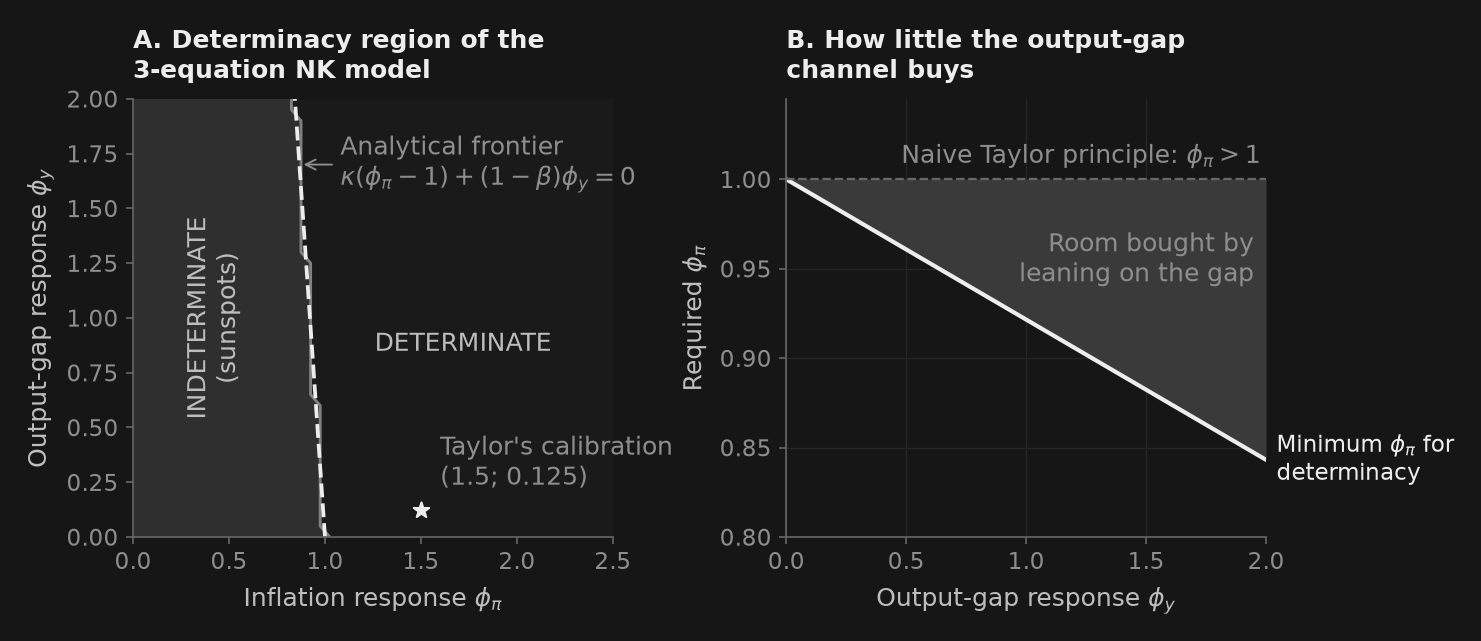

Grid points evaluated              : 2091
Share of the grid that is determinate: 62.9%
Numeric-vs-analytical mismatches   : 0
Required phi_pi at phi_y = 0.0     : 1.000
Required phi_pi at phi_y = 1.0     : 0.922
Required phi_pi at phi_y = 2.0     : 0.843

Determinacy assertions passed: the numerical QZ flags trace the textbook frontier exactly.


In [8]:
# ==============================================================================
# Determinacy Region over the (phi_pi, phi_y) Plane
# ==============================================================================
phi_pi_grid = np.linspace(0.0, 2.5, 51)
phi_y_grid = np.linspace(0.0, 2.0, 41)
determinacy = np.full((len(phi_y_grid), len(phi_pi_grid)), np.nan)

for j, p_y in enumerate(phi_y_grid):
    for i, p_pi in enumerate(phi_pi_grid):
        try:
            m_grid = load_mod(nk_mod_path, params={"phi_pi": float(p_pi), "phi_y": float(p_y)}, strict=False)
            determinacy[j, i] = 1.0 if m_grid.solution.eu == (1, 1) else 0.0
        except Exception:
            determinacy[j, i] = 0.0

# Analytical frontier: phi_pi = 1 - (1 - beta) * phi_y / kappa
beta_nk, kappa_nk = 0.99, 0.1275
frontier = 1.0 - (1.0 - beta_nk) * phi_y_grid / kappa_nk

fig, (ax_map, ax_zoom) = _nbstyle.figura(1, 2)

ax_map.contourf(phi_pi_grid, phi_y_grid, determinacy, levels=[-0.5, 0.5, 1.5],
                colors=[_nbstyle.gris("0.82"), _nbstyle.gris("0.97")])
ax_map.contour(phi_pi_grid, phi_y_grid, determinacy, levels=[0.5], colors=[_nbstyle.gris("0.35")], linewidths=1.4)
ax_map.plot(frontier, phi_y_grid, color=_nbstyle.TINTA, lw=1.8, ls="--")
ax_map.scatter([1.5], [0.125], color=_nbstyle.TINTA, s=60, zorder=6, marker="*")
ax_map.annotate("Analytical frontier\n$\\kappa(\\phi_\\pi-1)+(1-\\beta)\\phi_y=0$",
                xy=(float(np.interp(1.7, phi_y_grid, frontier)), 1.7), xytext=(1.08, 1.7),
                ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_map.annotate("Taylor's calibration\n(1.5; 0.125)", xy=(1.5, 0.125), xytext=(1.6, 0.2),
                ha="left", va="bottom", color=_nbstyle.NOTA)
ax_map.text(0.42, 1.0, "INDETERMINATE\n(sunspots)", color=_nbstyle.TEXTO, ha="center", va="center", rotation=90)
ax_map.text(1.72, 0.85, "DETERMINATE", color=_nbstyle.TEXTO, ha="center")
ax_map.set_xlim(0.0, 2.5)
ax_map.set_ylim(0.0, 2.0)
ax_map.set_title("A. Determinacy region of the\n3-equation NK model")
ax_map.set_xlabel(r"Inflation response $\phi_\pi$")
ax_map.set_ylabel(r"Output-gap response $\phi_y$")

# Zoom on the frontier: how much does the output gap actually buy?
ax_zoom.plot(phi_y_grid, frontier, **_nbstyle.S1, label="Minimum $\\phi_\\pi$ for\ndeterminacy")
ax_zoom.axhline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.1)
ax_zoom.fill_between(phi_y_grid, frontier, 1.0, color=_nbstyle.tono(0.2), lw=0)
ax_zoom.annotate("Naive Taylor principle: $\\phi_\\pi > 1$", xy=(1.98, 1.0), xytext=(0, 5),
                 textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)
ax_zoom.annotate("Room bought by\nleaning on the gap", xy=(1.95, 0.955),
                 ha="right", va="center", color=_nbstyle.NOTA)
ax_zoom.set_xlim(0.0, 2.0)
ax_zoom.set_ylim(0.80, 1.045)
ax_zoom.set_title("B. How little the output-gap\nchannel buys")
ax_zoom.set_xlabel(r"Output-gap response $\phi_y$")
ax_zoom.set_ylabel(r"Required $\phi_\pi$")
_nbstyle.etiquetar(ax_zoom, donde="fin")

plt.show()

# The numeric grid and the analytical frontier must agree at every row
mismatches = 0
for j, p_y in enumerate(phi_y_grid):
    boundary = frontier[j]
    for i, p_pi in enumerate(phi_pi_grid):
        if abs(p_pi - boundary) < 0.06:      # skip the cells straddling the boundary
            continue
        predicted = 1.0 if p_pi > boundary else 0.0
        mismatches += int(determinacy[j, i] != predicted)

share_determinate = float(np.nanmean(determinacy) * 100)
print(f"Grid points evaluated              : {determinacy.size}")
print(f"Share of the grid that is determinate: {share_determinate:.1f}%")
print(f"Numeric-vs-analytical mismatches   : {mismatches}")
print(f"Required phi_pi at phi_y = 0.0     : {1.0 - 0.0:.3f}")
print(f"Required phi_pi at phi_y = 1.0     : {1.0 - (1.0 - beta_nk) / kappa_nk:.3f}")
print(f"Required phi_pi at phi_y = 2.0     : {1.0 - 2.0 * (1.0 - beta_nk) / kappa_nk:.3f}")

assert mismatches == 0, f"Numeric determinacy map must match the analytical frontier, got {mismatches} mismatches."
assert determinacy[0, np.searchsorted(phi_pi_grid, 1.5)] == 1.0, "Taylor's own calibration must be determinate."
print("\nDeterminacy assertions passed: the numerical QZ flags trace the textbook frontier exactly.")


## The Taylor Curve: The Policy Frontier the Central Bank Actually Faces

The determinacy map says which rules are *admissible*. It says nothing about which admissible rule is *good*. Under cost-push shocks the divine coincidence fails, so the central bank cannot stabilize both inflation and the output gap, and every admissible rule delivers some pair $(\sigma_{\tilde y}, \sigma_\pi)$. The lower envelope of those pairs is the **Taylor curve** (Taylor 1979) — the efficient frontier of monetary policy, and the object every "dual mandate" argument is implicitly about.

We trace it exactly rather than by simulation. For each rule, `theoretical_moments` solves the Lyapunov equation $\Sigma_x = G\Sigma_x G^\top + N\Sigma_u N^\top$ and returns population standard deviations, so the frontier is computed to machine precision from a single cost-push shock of 50 bps.

Three readings are worth taking from the picture:
1. **The frontier is steeply convex.** Going from $\phi_\pi = 1.5$ to $\phi_\pi = 5$ cuts inflation volatility by almost 40% but costs over 80% more output-gap volatility. Aggressive inflation targeting is cheap at first and expensive later.
2. **The output-gap coefficient moves you *along* the frontier, not off it.** Raising $\phi_y$ trades in the opposite direction to $\phi_\pi$; the two coefficients are substitutes in choosing a point, not complements in reaching a better one.
3. **The interest-rate volatility that pays for it.** The rules at the low-inflation-volatility end require a policy rate that moves several times more than the baseline — the practical reason central banks do not sit there.

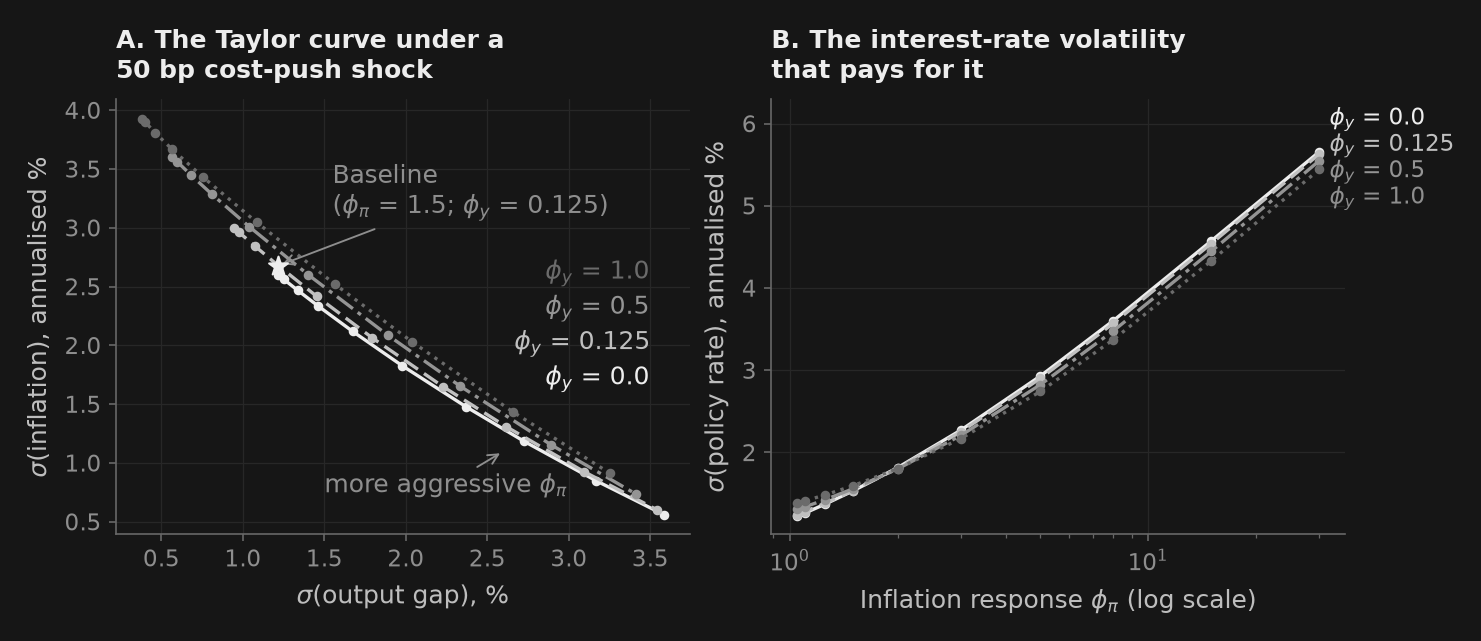

THE POLICY FRONTIER ALONG phi_y = 0.125 (Taylor's own output coefficient):
        sd(pi) annualised %  sd(y_gap) %  sd(i) annualised %
phi_pi                                                      
1.05                  3.002        0.944               1.244
1.10                  2.960        0.978               1.279
1.25                  2.843        1.075               1.380
1.50                  2.677        1.218               1.535
2.00                  2.417        1.452               1.808
3.00                  2.063        1.795               2.251
5.00                  1.648        2.229               2.900
8.00                  1.309        2.616               3.571
15.00                 0.927        3.092               4.540
30.00                 0.603        3.538               5.627

Moving from phi_pi = 1.5 to phi_pi = 5.0:
  inflation volatility  2.68 -> 1.65  (-38%)
  output-gap volatility 1.22 -> 2.23  (+83%)
  policy-rate volatility 1.54 -> 2.90

Taylor-curve assertio

In [9]:
# ==============================================================================
# The Taylor Curve: Inflation vs. Output-Gap Volatility under Cost-Push Shocks
# ==============================================================================
phi_pi_frontier = [1.05, 1.1, 1.25, 1.5, 2.0, 3.0, 5.0, 8.0, 15.0, 30.0]
phi_y_curves = [0.0, 0.125, 0.5, 1.0]
frontier_rows = []

for p_y in phi_y_curves:
    for p_pi in phi_pi_frontier:
        m_f = load_mod(nk_mod_path, params={"phi_pi": p_pi, "phi_y": p_y})
        # Only the cost-push shock is active; the demand shock's FEVD row is then
        # undefined, which is what the ZeroVarianceWarning reports. Moments are unaffected.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            tm_f = m_f.theoretical_moments(sigma={"eps_i": 0.0, "eps_rn": 0.0, "eps_u": 0.005})
        frontier_rows.append({
            "phi_y": p_y,
            "phi_pi": p_pi,
            "sd(pi) annualised %": tm_f.moments.loc["pi", "Std.Dev."] * 400,
            "sd(y_gap) %": tm_f.moments.loc["y_gap", "Std.Dev."] * 100,
            "sd(i) annualised %": tm_f.moments.loc["i", "Std.Dev."] * 400,
        })

frontier_df = pd.DataFrame(frontier_rows)

fig, (ax_tc, ax_irate) = _nbstyle.figura(1, 2)

tc_grays, tc_dashes = _nbstyle.palette(len(phi_y_curves)), _nbstyle.styles(len(phi_y_curves))
for j, p_y in enumerate(phi_y_curves):
    sub = frontier_df[frontier_df["phi_y"] == p_y]
    ax_tc.plot(sub["sd(y_gap) %"], sub["sd(pi) annualised %"], color=tc_grays[j], ls=tc_dashes[j],
               lw=1.6, marker="o", markersize=3.6, label=rf"$\phi_y$ = {p_y}")
    ax_irate.plot(sub["phi_pi"], sub["sd(i) annualised %"], color=tc_grays[j], ls=tc_dashes[j],
                  lw=1.6, marker="o", markersize=3.6, label=rf"$\phi_y$ = {p_y}")

base = frontier_df[(frontier_df["phi_pi"] == 1.5) & (frontier_df["phi_y"] == 0.125)].iloc[0]
ax_tc.scatter([base["sd(y_gap) %"]], [base["sd(pi) annualised %"]], color=_nbstyle.TINTA,
              s=90, marker="*", zorder=7)
ax_tc.annotate("Baseline\n($\\phi_\\pi$ = 1.5; $\\phi_y$ = 0.125)", xy=(base["sd(y_gap) %"], base["sd(pi) annualised %"]),
               xytext=(1.55, 3.3), ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_tc.annotate(r"more aggressive $\phi_\pi$", xy=(2.6, 1.1), xytext=(1.5, 0.75), color=_nbstyle.NOTA,
               arrowprops=_nbstyle.FLECHA)
ax_tc.set_title("A. The Taylor curve under a\n50 bp cost-push shock")
ax_tc.set_xlabel(r"$\sigma$(output gap), %")
ax_tc.set_ylabel(r"$\sigma$(inflation), annualised %")
# The four frontiers almost touch: their names are listed in the gap at the lower right,
# in the same vertical order as the curves
for ln, y_lab in zip(ax_tc.get_lines()[:len(phi_y_curves)], (1.6, 1.9, 2.2, 2.5)):
    ax_tc.annotate(ln.get_label(), xy=(3.5, y_lab), ha="right", va="bottom", color=ln.get_color())

ax_irate.set_xscale("log")
ax_irate.set_ylim(top=6.3)
ax_irate.set_title("B. The interest-rate volatility\nthat pays for it")
ax_irate.set_xlabel(r"Inflation response $\phi_\pi$ (log scale)")
ax_irate.set_ylabel(r"$\sigma$(policy rate), annualised %")
_nbstyle.etiquetar(ax_irate, donde="fin")

plt.show()

baseline_curve = frontier_df[frontier_df["phi_y"] == 0.125].set_index("phi_pi")
print("THE POLICY FRONTIER ALONG phi_y = 0.125 (Taylor's own output coefficient):")
print(baseline_curve[["sd(pi) annualised %", "sd(y_gap) %", "sd(i) annualised %"]].round(3).to_string())

pi_15, y_15 = baseline_curve.loc[1.5, "sd(pi) annualised %"], baseline_curve.loc[1.5, "sd(y_gap) %"]
pi_50, y_50 = baseline_curve.loc[5.0, "sd(pi) annualised %"], baseline_curve.loc[5.0, "sd(y_gap) %"]
print(f"\nMoving from phi_pi = 1.5 to phi_pi = 5.0:")
print(f"  inflation volatility  {pi_15:.2f} -> {pi_50:.2f}  ({(pi_50/pi_15 - 1)*100:+.0f}%)")
print(f"  output-gap volatility {y_15:.2f} -> {y_50:.2f}  ({(y_50/y_15 - 1)*100:+.0f}%)")
print(f"  policy-rate volatility {baseline_curve.loc[1.5, 'sd(i) annualised %']:.2f} -> "
      f"{baseline_curve.loc[5.0, 'sd(i) annualised %']:.2f}")

# The frontier must slope down: more inflation stabilisation costs output stability
for p_y in phi_y_curves:
    sub = frontier_df[frontier_df["phi_y"] == p_y].sort_values("phi_pi")
    assert sub["sd(pi) annualised %"].is_monotonic_decreasing, f"Inflation volatility must fall in phi_pi at phi_y={p_y}."
    assert sub["sd(y_gap) %"].is_monotonic_increasing, f"Output-gap volatility must rise in phi_pi at phi_y={p_y}."
print("\nTaylor-curve assertions passed: the trade-off is a genuine frontier, not a free lunch.")


## Calvo Stickiness: The Road Back to Money Neutrality

Everything the New Keynesian model does that the RBC model does not comes from one parameter: the Calvo probability $\theta$ that a firm cannot reset its price this quarter. It enters the model only through the slope of the Phillips curve,
$$ \kappa = \frac{(1-\theta)(1-\beta\theta)}{\theta}\,(\sigma + \varphi), $$
where $\varphi$ is the inverse Frisch elasticity. The baseline $\kappa = 0.1275$ at $\theta = 0.75$ (prices fixed for four quarters, roughly the Bils & Klenow 2004 / Nakamura & Steinsson 2008 range) pins $\varphi$, so the sweep below is internally consistent: only $\theta$ moves.

The limit $\theta \to 0$ is the model's own falsification test. With flexible prices the NKPC becomes vertical, the output gap must be zero at all times, and a monetary shock can move nothing real — **money is neutral**, exactly as in Notebooks A and B. The experiment measures how fast that neutrality arrives, using three summary statistics of a 25 bps tightening:

1. the **impact output-gap response**, which should vanish as $\theta \to 0$;
2. the **implied duration** of a price spell, $1/(1-\theta)$ quarters, which is what micro price data actually measure;
3. the **sacrifice ratio**, the cumulative output-gap loss per cumulative point of disinflation — the number that policy debates about the cost of bringing inflation down are really about.

Inverse Frisch elasticity implied by kappa = 0.1275 at theta = 0.75: phi = 0.4854


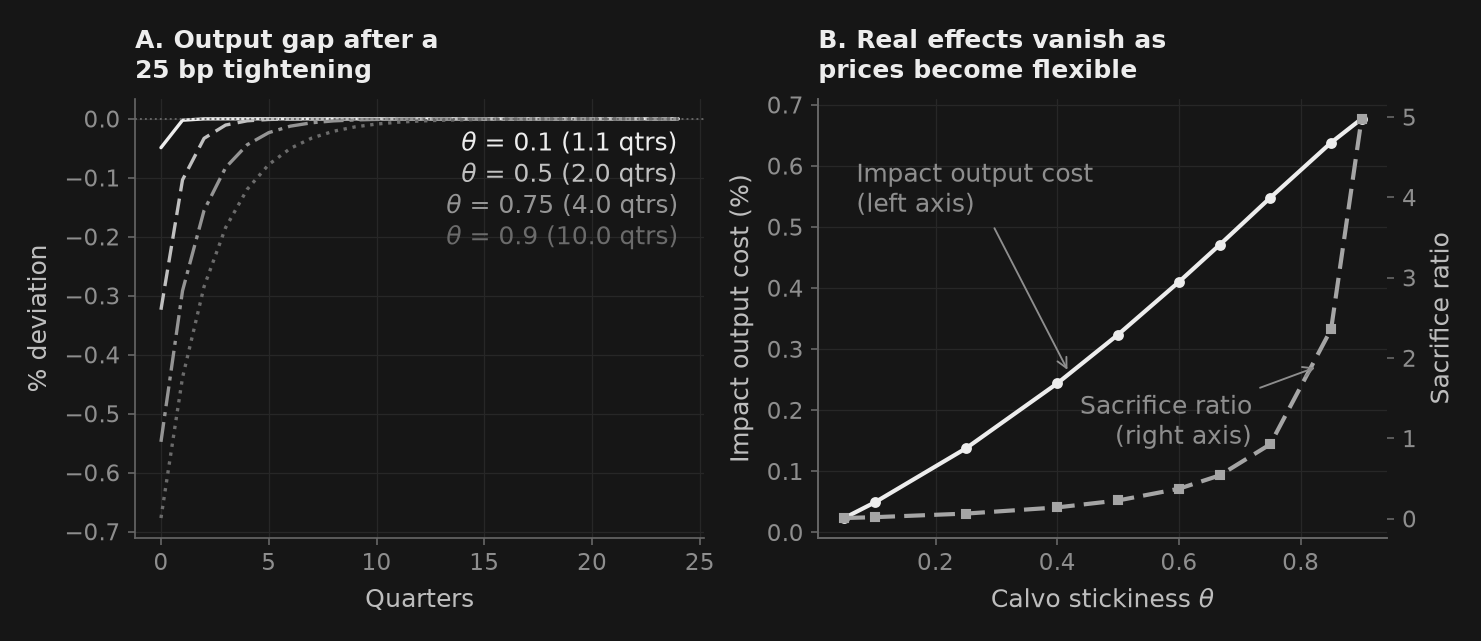


CALVO STICKINESS SWEEP (25 bps monetary tightening):
 theta  Price duration (quarters)  NKPC slope kappa  Impact y_gap (%)  Impact pi (ann. %)  Sacrifice ratio
 0.050                     1.0526           26.8262           -0.0234             -2.5755           0.0091
 0.100                     1.1111           12.0454           -0.0489             -2.4767           0.0198
 0.250                     1.3333            3.3534           -0.1375             -2.1340           0.0644
 0.400                     1.6667            1.3458           -0.2439             -1.7258           0.1413
 0.500                     2.0000            0.7501           -0.3238             -1.4217           0.2278
 0.600                     2.5000            0.4021           -0.4101             -1.0973           0.3738
 0.667                     3.0030            0.2519           -0.4708             -0.8720           0.5399
 0.750                     4.0000            0.1275           -0.5478             -0.5909 

In [10]:
# ==============================================================================
# Calvo Sweep: From Fixed Prices to the Flexible-Price Neutrality Limit
# ==============================================================================
BETA_C, SIGMA_C = 0.99, 1.0
THETA_BASE, KAPPA_BASE = 0.75, 0.1275


def calvo_lambda(theta):
    """The Calvo reset factor (1 - theta)(1 - beta*theta) / theta."""
    return (1.0 - theta) * (1.0 - BETA_C * theta) / theta


# Back out the inverse Frisch elasticity that reproduces the notebook's baseline kappa
phi_frisch = KAPPA_BASE / calvo_lambda(THETA_BASE) - SIGMA_C
print(f"Inverse Frisch elasticity implied by kappa = {KAPPA_BASE} at theta = {THETA_BASE}: phi = {phi_frisch:.4f}")

theta_grid = [0.05, 0.10, 0.25, 0.40, 0.50, 0.60, 0.667, 0.75, 0.85, 0.90]
calvo_rows = []
irf_store = {}

for theta in theta_grid:
    kappa_theta = calvo_lambda(theta) * (SIGMA_C + phi_frisch)
    m_theta = load_mod(nk_mod_path, params={"kappa": float(kappa_theta)})
    irf_theta = m_theta.irf("eps_i", horizon=24, size=0.0025)
    cum_gap = irf_theta["y_gap"].sum() * 100.0        # cumulative output-gap loss, % quarters
    cum_pi = irf_theta["pi"].sum() * 400.0            # cumulative disinflation, annualised points
    calvo_rows.append({
        "theta": theta,
        "Price duration (quarters)": 1.0 / (1.0 - theta),
        "NKPC slope kappa": kappa_theta,
        "Impact y_gap (%)": irf_theta.loc[0, "y_gap"] * 100,
        "Impact pi (ann. %)": irf_theta.loc[0, "pi"] * 400,
        "Sacrifice ratio": cum_gap / cum_pi,
    })
    if theta in (0.10, 0.50, 0.75, 0.90):
        irf_store[theta] = irf_theta

calvo_df = pd.DataFrame(calvo_rows)

fig, (ax_irf_c, ax_sac) = _nbstyle.figura(1, 2)

# Panel 1: output-gap responses across stickiness
calvo_grays, calvo_dashes = _nbstyle.palette(len(irf_store)), _nbstyle.styles(len(irf_store))
for j, (theta, irf_theta) in enumerate(sorted(irf_store.items())):
    ax_irf_c.plot(irf_theta.index, irf_theta["y_gap"] * 100, color=calvo_grays[j], ls=calvo_dashes[j], lw=1.6,
                  label=rf"$\theta$ = {theta} ({1/(1-theta):.1f} qtrs)")
ax_irf_c.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_irf_c.set_title("A. Output gap after a\n25 bp tightening")
ax_irf_c.set_xlabel("Quarters")
ax_irf_c.set_ylabel("% deviation")
# The four curves end together at zero: they are named stacked next to that common endpoint,
# from the shallowest to the deepest (the same vertical order they have on impact)
for k, ln in enumerate(ax_irf_c.get_lines()[:len(irf_store)]):
    ax_irf_c.annotate(ln.get_label(), xy=(24, 0.0), xytext=(0, -6 - 15 * k), textcoords="offset points",
                      ha="right", va="top", color=ln.get_color())

# Panel 2: impact response and sacrifice ratio against stickiness
ax_sac.plot(calvo_df["theta"], -calvo_df["Impact y_gap (%)"], **_nbstyle.S1, marker="o", markersize=4.2)
ax_sac.set_xlabel(r"Calvo stickiness $\theta$")
ax_sac.set_ylabel("Impact output cost (%)")
ax_sac.set_title("B. Real effects vanish as\nprices become flexible")
ax_twin = ax_sac.twinx()
ax_twin.plot(calvo_df["theta"], calvo_df["Sacrifice ratio"], **_nbstyle.S2, marker="s", markersize=3.8)
ax_twin.set_ylabel("Sacrifice ratio")
ax_twin.grid(False)   # one grid per panel: the left axis'"'"' own
ax_sac.annotate("Impact output cost\n(left axis)", xy=(0.42, 0.26), xytext=(0.07, 0.56),
                ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_twin.annotate("Sacrifice ratio\n(right axis)", xy=(0.83, 1.9), xytext=(0.72, 1.2),
                 ha="right", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

plt.show()

print("\nCALVO STICKINESS SWEEP (25 bps monetary tightening):")
print(calvo_df.round(4).to_string(index=False))

flex = calvo_df.iloc[0]
sticky = calvo_df.iloc[-1]
base_row = calvo_df[calvo_df["theta"] == 0.75].iloc[0]
print(f"\nNear-flexible prices (theta = {flex['theta']}, duration {flex['Price duration (quarters)']:.1f} quarters):")
print(f"   impact output gap {flex['Impact y_gap (%)']:+.3f}%, sacrifice ratio {flex['Sacrifice ratio']:.3f}")
print(f"Baseline (theta = 0.75, one year):")
print(f"   impact output gap {base_row['Impact y_gap (%)']:+.3f}%, sacrifice ratio {base_row['Sacrifice ratio']:.2f}")
print(f"Very sticky (theta = {sticky['theta']}, {sticky['Price duration (quarters)']:.0f} quarters):")
print(f"   impact output gap {sticky['Impact y_gap (%)']:+.3f}%, sacrifice ratio {sticky['Sacrifice ratio']:.2f}")
print(f"\nThe real effect of money shrinks by a factor of "
      f"{abs(sticky['Impact y_gap (%)'] / flex['Impact y_gap (%)']):.0f} between the two extremes.")

assert abs(flex["Impact y_gap (%)"]) < 0.05, "With near-flexible prices the monetary shock must be almost neutral."
assert calvo_df["Sacrifice ratio"].is_monotonic_increasing, "Stickier prices must make disinflation more costly."
assert calvo_df["NKPC slope kappa"].is_monotonic_decreasing, "The Phillips curve must flatten as theta rises."
print("\nCalvo assertions passed: the New Keynesian model contains the neutrality benchmark as a limiting case.")


## The Shimer Puzzle Measured, and the Beveridge Curve Done Right

Section 5 read the Shimer puzzle off a single impulse response. The literature states it as a **moment**: the standard deviation of HP-filtered $\log \theta_t$ relative to that of HP-filtered $\log(y_t / n_t l_t)$. Shimer's own figure for the US is roughly 20; the flagship exercise in the slide deck measures about 25 on the JOLTS/OPHNFB sample since 2001. The `.mod` file carries `lth` $= \log\theta$ and `lpr` $= \log\mathrm{prod}$ precisely so the model side can be computed the same way.

There is also a measurement trap here worth pausing on. The model exposes **two** unemployment concepts, and they behave in opposite directions:
- `urate` counts non-employed people **weighted by search intensity** $x_t$. Because $x_t$ is procyclical, this series is nearly acyclical, and plotting it against vacancies produces an *upward*-sloping Beveridge curve — an artefact of the weighting, not an economic finding.
- `u_head` is unemployment **by heads**, $1 - n_{t-1}$. This is the object the slides plot, and it is properly countercyclical.

The experiment computes the amplification ratio on a long simulated sample, plots both unemployment measures against vacancies, and then asks whether any parameter in the model can rescue the amplification: the vacancy-posting cost $\kappa$, the separation rate $s$, the matching elasticity $\phi$, and the persistence of the technology shock $\rho_a$. The answer decides whether the Shimer puzzle is a calibration failure or a structural one.

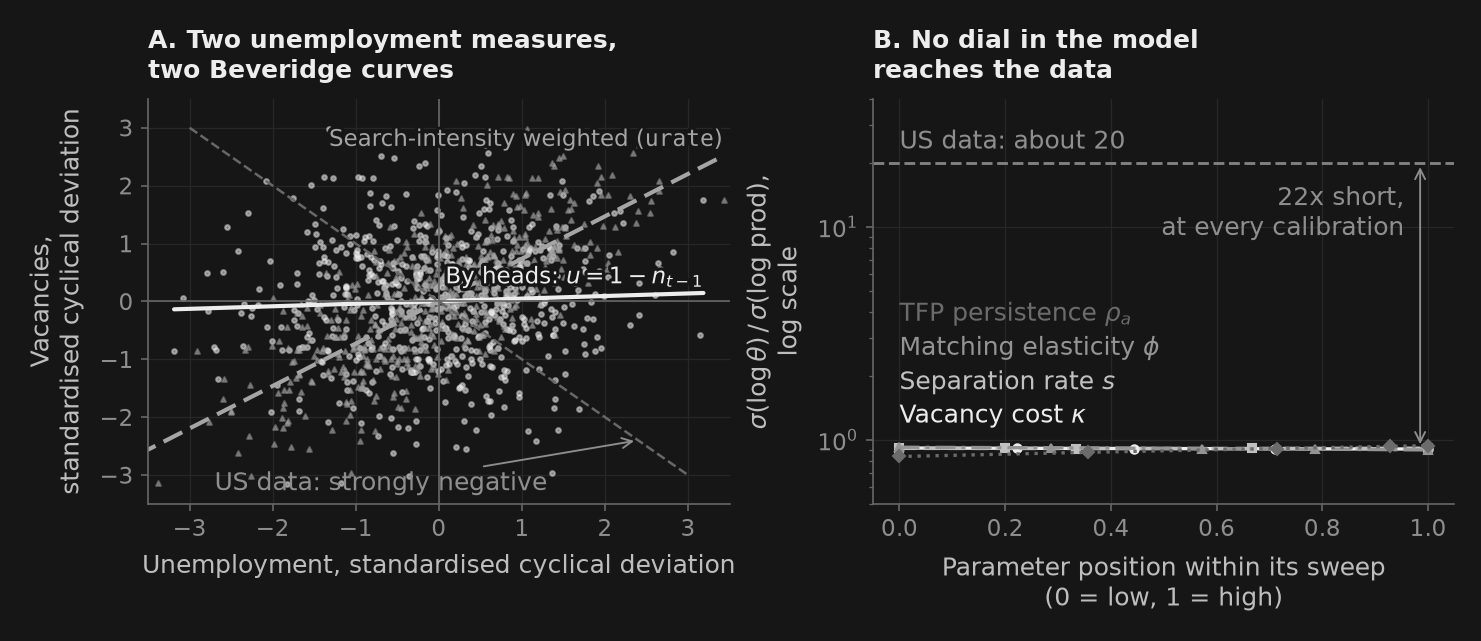

MERZ-ANDOLFATTO AT THE COURSE CALIBRATION (3,000 quarters, HP lambda = 1600):
  sd(log theta)                = 0.701%
  sd(log productivity)         = 0.767%
  Amplification ratio          = 0.914   (US data about 20)
  The model falls short by a factor of 22.

THE BEVERIDGE CURVE DEPENDS ON WHICH UNEMPLOYMENT YOU PLOT:
  corr(u by heads, v)          = +0.071   (US data about -0.9)
  corr(search-weighted u, v)   = +0.756   (an artefact of the weighting)
  corr(u by heads, y)          = -0.775   (correctly countercyclical)
  sd(u by heads) = 0.195% against sd(v) = 1.192%: unemployment barely moves, which is the puzzle in another guise.

PARAMETER SWEEPS -- AMPLIFICATION RATIO:
  Vacancy cost $\kappa$            values [0.1, 0.2, 0.3, 0.42, 0.55] -> ratio 0.91 to 0.92
  Separation rate $s$              values [0.05, 0.08, 0.1, 0.15, 0.2] -> ratio 0.91 to 0.91
  Matching elasticity $\phi$       values [0.3, 0.4, 0.5, 0.575, 0.65] -> ratio 0.90 to 0.92
  TFP persistence $\rho_a$         va

In [11]:
# ==============================================================================
# The Shimer Amplification Ratio and the Two Faces of Unemployment
# ==============================================================================
from puremacro.data import hp_filter


def shimer_moments(model, periods=3000, seed=20260906, burn=400):
    """HP-filtered amplification ratio sd(log theta)/sd(log prod) and Beveridge correlations."""
    raw = model.simulate(periods=periods, seed=seed, burn=burn)
    ss_here = {n: float(v) for n, v in zip(model.variables, model.decision_rules().to_frame().loc["Constant"])}
    # lth and lpr are already logs, so their deviations are log points
    cyc_lth = hp_filter(pd.Series(raw["lth"].values), lamb=1600.0)[0]
    cyc_lpr = hp_filter(pd.Series(raw["lpr"].values), lamb=1600.0)[0]
    logs = {v: 100.0 * np.log((ss_here[v] + raw[v].values) / ss_here[v]) for v in ("v", "u_head", "urate", "y")}
    cyc_lv = {v: hp_filter(pd.Series(s), lamb=1600.0)[0] for v, s in logs.items()}
    return {
        "ratio": float(cyc_lth.std() / cyc_lpr.std()),
        "sd_lth_pct": float(cyc_lth.std() * 100),
        "sd_lpr_pct": float(cyc_lpr.std() * 100),
        "corr_uhead_v": float(cyc_lv["u_head"].corr(cyc_lv["v"])),
        "corr_urate_v": float(cyc_lv["urate"].corr(cyc_lv["v"])),
        "corr_uhead_y": float(cyc_lv["u_head"].corr(cyc_lv["y"])),
        "sd_uhead_pct": float(cyc_lv["u_head"].std()),
        "sd_v_pct": float(cyc_lv["v"].std()),
        "cycles": cyc_lv,
    }


base_ma = shimer_moments(m_ma)
DATA_RATIO = 20.0   # Shimer (2005); the slide-deck JOLTS/OPHNFB exercise reads about 25

fig, (ax_bev2, ax_amp) = _nbstyle.figura(1, 2)

# Panel 1: the two unemployment concepts against vacancies.
# Unemployment by heads moves 6x less than the search-weighted measure (0.20% vs 1.19%),
# so both axes are standardised: the fitted slope is then exactly the correlation.
sample = slice(0, 600)
v_z = (base_ma["cycles"]["v"].values[sample] / base_ma["cycles"]["v"].std())
specs = (("u_head", _nbstyle.S1, "o", "By heads: $u = 1 - n_{t-1}$"),
         ("urate", _nbstyle.S2, "^", "Search-intensity weighted ($\\mathtt{urate}$)"))
for key, sty, mark, lab in specs:
    u_z = base_ma["cycles"][key].values[sample] / base_ma["cycles"][key].std()
    ax_bev2.scatter(u_z, v_z, s=5, color=sty["color"], alpha=0.5, marker=mark)
    slope, intercept = np.polyfit(u_z, v_z, 1)
    xline = np.linspace(u_z.min(), u_z.max(), 20)
    ax_bev2.plot(xline, intercept + slope * xline, **sty, label=lab)
ax_bev2.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_bev2.axvline(0, color=_nbstyle.SPINE, lw=0.8)
ax_bev2.plot([-3, 3], [3, -3], color=_nbstyle.SPINE, ls="--", lw=1.2)
ax_bev2.annotate("US data: strongly negative", xy=(2.4, -2.4), xytext=(-2.7, -3.15),
                 ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_bev2.set_xlim(-3.5, 3.5)
ax_bev2.set_ylim(-3.5, 3.5)
ax_bev2.set_title("A. Two unemployment measures,\ntwo Beveridge curves")
ax_bev2.set_xlabel("Unemployment, standardised cyclical deviation")
ax_bev2.set_ylabel("Vacancies,\nstandardised cyclical deviation")
_nbstyle.etiquetar(ax_bev2, donde="fin")

# Panel 2: does any parameter rescue the amplification?
# Ranges are capped where the .mod file's own initval still lets the steady-state
# solver converge (kappa above ~0.55 and phi above ~0.65 need a fresh initial guess).
sweeps = {
    r"Vacancy cost $\kappa$": ("kappa", [0.10, 0.20, 0.30, 0.42, 0.55]),
    r"Separation rate $s$": ("s", [0.05, 0.08, 0.10, 0.15, 0.20]),
    r"Matching elasticity $\phi$": ("phi", [0.30, 0.40, 0.50, 0.575, 0.65]),
    r"TFP persistence $\rho_a$": ("rho_a", [0.85, 0.90, 0.95, 0.98, 0.99]),
}
sweep_out = {}
markers_sw = ("o", "s", "^", "D")
sw_grays, sw_dashes = _nbstyle.palette(len(sweeps)), _nbstyle.styles(len(sweeps))
for j, (label, (par, values)) in enumerate(sweeps.items()):
    ratios = []
    for val in values:
        # Harmless: puremacro's steady-state solver probes the call signature with every variable at 1, which divides by zero in this model's equations; at two of these sweep values it also probes a negative tightness, where the .mod's own lth = log(theta) has no value. Both probes are discarded
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="divide by zero encountered in scalar divide", category=RuntimeWarning)
            warnings.filterwarnings("ignore", message="invalid value encountered in log", category=RuntimeWarning)
            m_sw = load_mod(ma_mod_path, params={par: float(val)})
        ratios.append(shimer_moments(m_sw, periods=2000, seed=77)["ratio"])
    # Normalise each parameter to [0, 1] so four sweeps share one axis
    grid01 = (np.array(values) - min(values)) / (max(values) - min(values))
    sweep_out[label] = (values, ratios)
    ax_amp.plot(grid01, ratios, color=sw_grays[j], ls=sw_dashes[j], lw=1.6, marker=markers_sw[j],
                markersize=4, label=label)

ax_amp.axhline(DATA_RATIO, color=_nbstyle.gris("0.35"), ls="--", lw=1.4)
ax_amp.annotate(f"US data: about {DATA_RATIO:.0f}", xy=(0.0, DATA_RATIO), xytext=(0, 4),
                textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
ax_amp.annotate("", xy=(0.985, DATA_RATIO), xytext=(0.985, base_ma["ratio"]),
                arrowprops={**_nbstyle.FLECHA, "arrowstyle": "<->"})
ax_amp.text(0.955, 16.0, f"{DATA_RATIO / base_ma['ratio']:.0f}x short,\nat every calibration",
            color=_nbstyle.NOTA, ha="right", va="top")
ax_amp.set_yscale("log")
ax_amp.set_ylim(0.5, 40)
ax_amp.set_xlabel("Parameter position within its sweep\n(0 = low, 1 = high)")
ax_amp.set_ylabel(r"$\sigma(\log\theta)\,/\,\sigma(\log\,\mathrm{prod})$," "\nlog scale")
ax_amp.set_title("B. No dial in the model\nreaches the data")
# The four curves overlap just above 0.9: their names are listed right above them
for ln, y_lab in zip(ax_amp.get_lines()[:len(sweeps)], (1.12, 1.62, 2.35, 3.4)):
    ax_amp.annotate(ln.get_label(), xy=(0.0, y_lab), ha="left", va="bottom", color=ln.get_color())

plt.show()

print("MERZ-ANDOLFATTO AT THE COURSE CALIBRATION (3,000 quarters, HP lambda = 1600):")
print(f"  sd(log theta)                = {base_ma['sd_lth_pct']:.3f}%")
print(f"  sd(log productivity)         = {base_ma['sd_lpr_pct']:.3f}%")
print(f"  Amplification ratio          = {base_ma['ratio']:.3f}   (US data about {DATA_RATIO:.0f})")
print(f"  The model falls short by a factor of {DATA_RATIO / base_ma['ratio']:.0f}.")
print("\nTHE BEVERIDGE CURVE DEPENDS ON WHICH UNEMPLOYMENT YOU PLOT:")
print(f"  corr(u by heads, v)          = {base_ma['corr_uhead_v']:+.3f}   (US data about -0.9)")
print(f"  corr(search-weighted u, v)   = {base_ma['corr_urate_v']:+.3f}   (an artefact of the weighting)")
print(f"  corr(u by heads, y)          = {base_ma['corr_uhead_y']:+.3f}   (correctly countercyclical)")
print(f"  sd(u by heads) = {base_ma['sd_uhead_pct']:.3f}% against sd(v) = {base_ma['sd_v_pct']:.3f}%: "
      "unemployment barely moves, which is the puzzle in another guise.")

print("\nPARAMETER SWEEPS -- AMPLIFICATION RATIO:")
for label, (values, ratios) in sweep_out.items():
    span = f"{min(ratios):.2f} to {max(ratios):.2f}"
    print(f"  {label:<32} values {values} -> ratio {span}")

all_ratios = [r for _, ratios in sweep_out.values() for r in ratios]
assert base_ma["ratio"] < 1.5, "The model's amplification must be an order of magnitude below the data."
assert max(all_ratios) < 2.0, "No single-parameter change may close the Shimer gap."
assert base_ma["corr_uhead_y"] < -0.5, "Unemployment by heads must be countercyclical."
assert base_ma["corr_urate_v"] > base_ma["corr_uhead_v"], (
    "The search-weighted measure must give the flatter/upward-sloping Beveridge relation."
)
print("\nShimer assertions passed: the puzzle survives every parameter in this model, "
      "which is why the fixes in the literature are structural (rigid wages, small surplus), not calibrational.")


## Two-Sided Kalman Smoothing & Historical Shock Decomposition: Anatomy of Post-COVID Inflation

The inflation surge of 2021–2023 (peaking above $8\%$ annualized in the United States) reignited foundational debates in monetary economics: **was the price surge driven primarily by aggregate demand overheating (fiscal stimulus, ultra-low policy rates) or by adverse supply disruptions (global shipping bottlenecks, energy shocks, labor market frictions)?** (Bernanke & Blanchard 2023, Gagliardone & Gertler 2023).

The 3-equation New Keynesian model provides the structural lens to resolve this debate. Its state-space representation relates the three observable variables:
$$\mathcal{Y}_t = \begin{bmatrix} y_t^{\text{gap}} \\ \pi_t \\ i_t \end{bmatrix}$$
to three orthogonal structural innovations:
1. **Supply Cost-Push Shocks ($u_t$, $\varepsilon_{u,t}$)**: Shifts the New Keynesian Phillips Curve directly, forcing inflation upward for any given output gap.
2. **Natural Rate / Aggregate Demand Shocks ($r^n_t$, $\varepsilon_{rn,t}$)**: Shifts the dynamic IS curve, altering output and price pressures via preference and expenditure windfalls.
3. **Monetary Policy Innovations ($\varepsilon_{i,t}$)**: Deviations of the nominal policy rate from the systematic Taylor rule.

Using `puremacro.dsge.LinearModel.smoother(data, varobs=...)`, we distinguish between the **filtered state** $\hat{x}_{t \mid t} = \mathbb{E}[x_t \mid \mathcal{Y}_t]$ (conditioned on contemporaneous information) and the **two-sided smoothed state** $\hat{x}_t = \mathbb{E}[x_t \mid \mathcal{Y}_T]$ (conditioned on the full sample). From the terminal Kalman smoother, the historical shock decomposition (`sm.shock_decomposition()`) evaluates the exact quarter-by-quarter contribution of supply cost-push, demand, and monetary policy shocks to the observed inflation path, satisfying the machine-precision adding-up identity.

POST-COVID INFLATION HISTORICAL SHOCK DECOMPOSITION (Annualized % Points)
            eps_u  eps_rn  eps_i  actual
date                                    
2020-03-31  -2.21   -0.87   0.21   -2.86
2020-06-30   2.50   -5.66  -0.45   -3.61
2020-09-30   2.67   -0.62   0.52    2.57
2020-12-31   0.88   -0.51   0.77    1.14
2021-03-31   1.43   -0.26   1.26    2.43
2021-06-30   3.88    0.12   2.49    6.50
2021-09-30   0.49   -0.03   2.33    2.78
2021-12-31   4.13    0.39   3.48    8.00
2022-03-31   3.99   -0.30   3.92    7.61
2022-06-30   4.47   -0.30   3.83    8.00
2022-09-30  -1.81    0.26   1.44   -0.12
2022-12-31   0.36    0.72   0.25    1.34
2023-03-31   1.20    0.88  -0.10    1.98


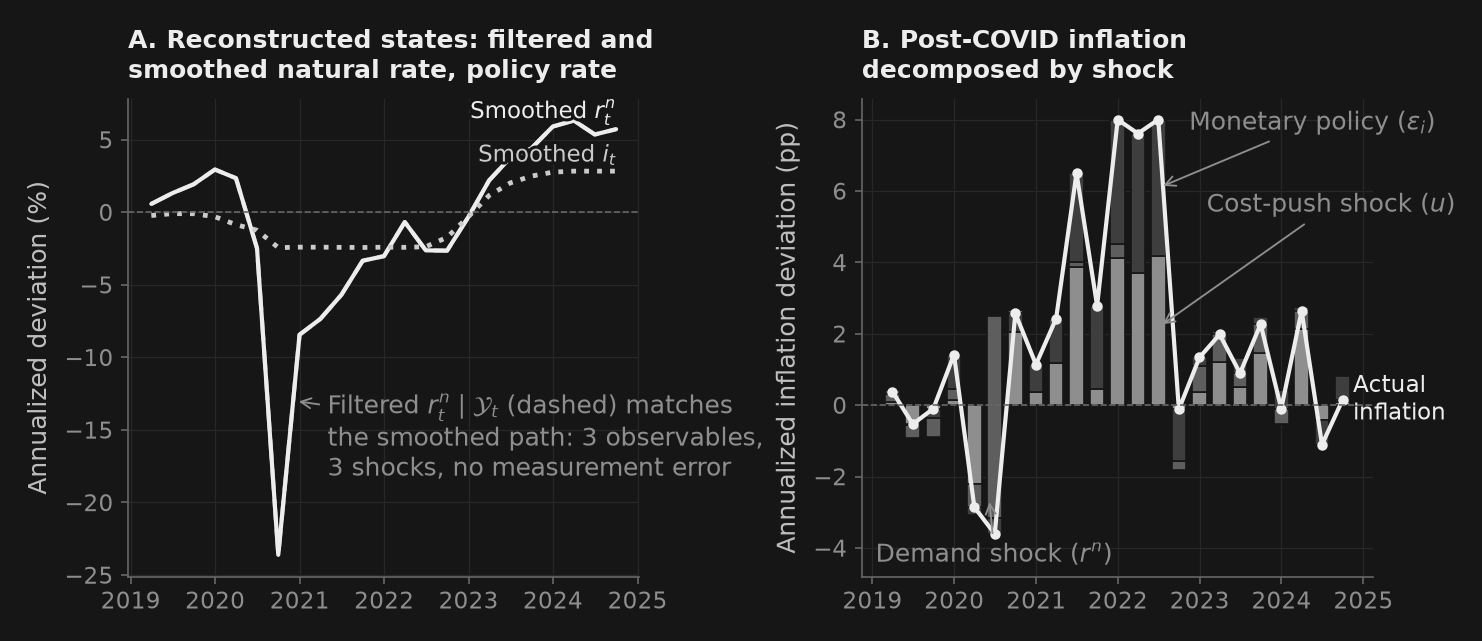


Historical inflation shock decomposition assertions successfully passed!


In [12]:
# ==============================================================================
# Historical Structural Shock Decomposition of Post-COVID Inflation (2019-2024)
# ==============================================================================
# 1. Load and prepare empirical series: CPI, Real GDP, and Federal Funds Rate
cpi_path = ruta_dato("CPIAUCSL.csv")
gdp_path = ruta_dato("GDPC1.csv")
ff_path  = ruta_dato("FEDFUNDS.csv")

cpi_df = pd.read_csv(cpi_path)
cpi_df["date"] = pd.to_datetime(cpi_df["observation_date"])
cpi_df = cpi_df.set_index("date").sort_index()

gdp_df = pd.read_csv(gdp_path)
gdp_df["date"] = pd.to_datetime(gdp_df["observation_date"])
gdp_df = gdp_df.set_index("date").sort_index()

ff_df = pd.read_csv(ff_path)
ff_df["date"] = pd.to_datetime(ff_df["observation_date"])
ff_df = ff_df.set_index("date").sort_index()

# Quarterly CPI annualized inflation deviation from 2% target
cpi_q = cpi_df["CPIAUCSL"].resample("QE").last()
infl_dev_ann = 400.0 * np.log(cpi_q / cpi_q.shift(1)) - 2.0  # Ann. percentage points

# Quarterly average Fed Funds rate deviation from 2.5% neutral rate
ff_q = ff_df["FEDFUNDS"].resample("QE").mean()
rate_dev_q = (ff_q - 2.5) / 400.0  # Quarterly fraction deviation

# Output gap: HP-filtered log real GDP
gdp_q = gdp_df["GDPC1"].resample("QE").last()
gap_cycle, _ = hp_filter(np.log(gdp_q), lamb=1600.0)

# Construct aligned empirical DataFrame
df_post_covid = pd.DataFrame({
    "y_gap": gap_cycle,
    "pi": infl_dev_ann / 400.0,
    "i": rate_dev_q
}).loc["2019-01-01":"2024-10-01"].dropna()

# 2. Kalman Smoothing and Historical Shock Decomposition with Course New Keynesian Model
sm_nk = m_nk.smoother(df_post_covid, varobs=["y_gap", "pi", "i"])
decomp_nk = sm_nk.shock_decomposition()

# Verify exact adding-up decomposition identity across all observables
for var in ["y_gap", "pi", "i"]:
    comp = decomp_nk.components[var]
    recon = comp[list(m_nk.shocks)].sum(axis=1) + comp["initial_condition"] + comp["steady_state"] + comp["residual"]
    assert np.allclose(recon, comp["actual"], atol=1e-12), f"Adding-up identity failed for {var}"
    assert np.all(np.abs(comp["residual"]) < 1e-11), f"Smoothed residual non-zero for {var}"

# Inflation decomposition in annualized percentage points
pi_decomp = decomp_nk.components["pi"] * 400.0

print("=" * 76)
print("POST-COVID INFLATION HISTORICAL SHOCK DECOMPOSITION (Annualized % Points)")
print("=" * 76)
crisis_table = pi_decomp[["eps_u", "eps_rn", "eps_i", "actual"]].loc["2020-03-31":"2023-03-31"]
print(crisis_table.round(2).to_string())
print("=" * 76)

# 3. Two-Sided Kalman State Reconstruction vs. Filtered State
fig, (ax_st, ax_dec) = _nbstyle.figura(1, 2)

dates = pi_decomp.index
# State Reconstruction: Filtered vs. Smoothed Natural Real Rate & Policy Rate
ax_st.plot(dates, sm_nk.filtered_states["rn"] * 400, **_nbstyle.S2)
ax_st.plot(dates, sm_nk.states["rn"] * 400, **_nbstyle.S1, label="Smoothed $r^n_t$")
ax_st.plot(dates, sm_nk.states["i"] * 400, **_nbstyle.S4, label="Smoothed $i_t$")
# With three observables and three shocks the filter already pins the state down: the
# filtered path (dashed) sits exactly underneath the smoothed one
ax_st.annotate("Filtered $r^n_t \\mid \\mathcal{Y}_t$ (dashed) matches\nthe smoothed path: 3 observables,\n3 shocks, no measurement error",
               xy=(pd.Timestamp("2020-12-10"), -13.0), xytext=(pd.Timestamp("2021-05-01"), -15.5),
               ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_st.axhline(0, color=_nbstyle.SPINE, ls="--", lw=0.8)
ax_st.set_title("A. Reconstructed states: filtered and\nsmoothed natural rate, policy rate")
ax_st.set_ylabel("Annualized deviation (%)")
_nbstyle.etiquetar(ax_st, donde="fin")

# Stacked Shock Decomposition Bar Chart for Inflation
width = 65  # bar width in days
ax_dec.bar(dates, pi_decomp["eps_u"], width=width, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=0.8)
ax_dec.bar(dates, pi_decomp["eps_rn"], width=width, bottom=pi_decomp["eps_u"], color=_nbstyle.BARRA_COLORES[2], edgecolor=_nbstyle.FONDO, lw=0.8)
ax_dec.bar(dates, pi_decomp["eps_i"], width=width, bottom=pi_decomp["eps_u"] + pi_decomp["eps_rn"], color=_nbstyle.BARRA_COLORES[3], edgecolor=_nbstyle.FONDO, lw=0.8)
ax_dec.plot(dates, pi_decomp["actual"], **_nbstyle.S1, marker="o", markersize=4, label="Actual\ninflation")
ax_dec.axhline(0, color=_nbstyle.SPINE, ls="--", lw=0.8)
# The stacked segments are named where each shock dominates the bar
ax_dec.annotate("Monetary policy ($\\varepsilon_i$)", xy=(pd.Timestamp("2022-07-05"), 6.1),
                xytext=(pd.Timestamp("2022-11-15"), 7.9), ha="left", va="center", color=_nbstyle.NOTA,
                arrowprops=_nbstyle.FLECHA)
ax_dec.annotate("Cost-push shock ($u$)", xy=(pd.Timestamp("2022-07-05"), 2.2),
                xytext=(pd.Timestamp("2023-02-01"), 5.6), ha="left", va="center", color=_nbstyle.NOTA,
                arrowprops=_nbstyle.FLECHA)
ax_dec.annotate("Demand shock ($r^n$)", xy=(pd.Timestamp("2020-06-05"), -2.6),
                xytext=(pd.Timestamp("2019-01-15"), -4.2), ha="left", va="center", color=_nbstyle.NOTA,
                arrowprops=_nbstyle.FLECHA)
ax_dec.set_ylim(bottom=-4.8)
ax_dec.set_title("B. Post-COVID inflation\ndecomposed by shock")
ax_dec.set_ylabel("Annualized inflation deviation (pp)")
_nbstyle.etiquetar(ax_dec, donde="fin")

plt.show()

# Verification Assertions
peak_cost_push = float(pi_decomp.loc["2021-06-01":"2022-06-30", "eps_u"].max())
lockdown_demand = float(pi_decomp.loc["2020-06-30", "eps_rn"])

assert peak_cost_push > 3.0, f"Cost-push shocks must account for >3pp of peak 2021-22 inflation: {peak_cost_push:.2f}"
assert lockdown_demand < -3.0, f"COVID lockdown demand shock must be < -3pp: {lockdown_demand:.2f}"
print("\nHistorical inflation shock decomposition assertions successfully passed!")


## Dynamic DSGE Forecasting: Model-Consistent Forward Projections & Fan Charts

A core function of structural DSGE models in central banks (e.g., Federal Reserve, ECB, Bank of England, Banco de México) is **conditional scenario forecasting and uncertainty quantification**.

Given the filtered terminal state $\hat{x}_T = \mathbb{E}[x_T \mid \mathcal{Y}_T]$ and its estimation error covariance $P_T = \mathbb{E}[(x_T - \hat{x}_T)(x_T - \hat{x}_T)' \mid \mathcal{Y}_T]$, `puremacro.dsge.LinearModel.forecast(horizon=H, data=data, ci=0.90)` computes the forward expectations under rational expectations:
$$\mathbb{E}_T[\mathcal{Y}_{T+h}] = d + Z A^h \hat{x}_T$$
with model-consistent shock uncertainty covariance:
$$\mathbb{V}_T[\mathcal{Y}_{T+h}] = Z P_{T+h \mid T} Z' + H$$
where $P_{T+h \mid T} = A P_{T+h-1 \mid T} A' + B Q B'$.

Below, we project forward across horizon $H=12$ quarters conditioned on the terminal 2024Q3/Q4 state, generating publication-grade fan charts for inflation $\pi_t$ and the output gap $y_t^{\text{gap}}$ with $90\%$ model-consistent confidence bands.

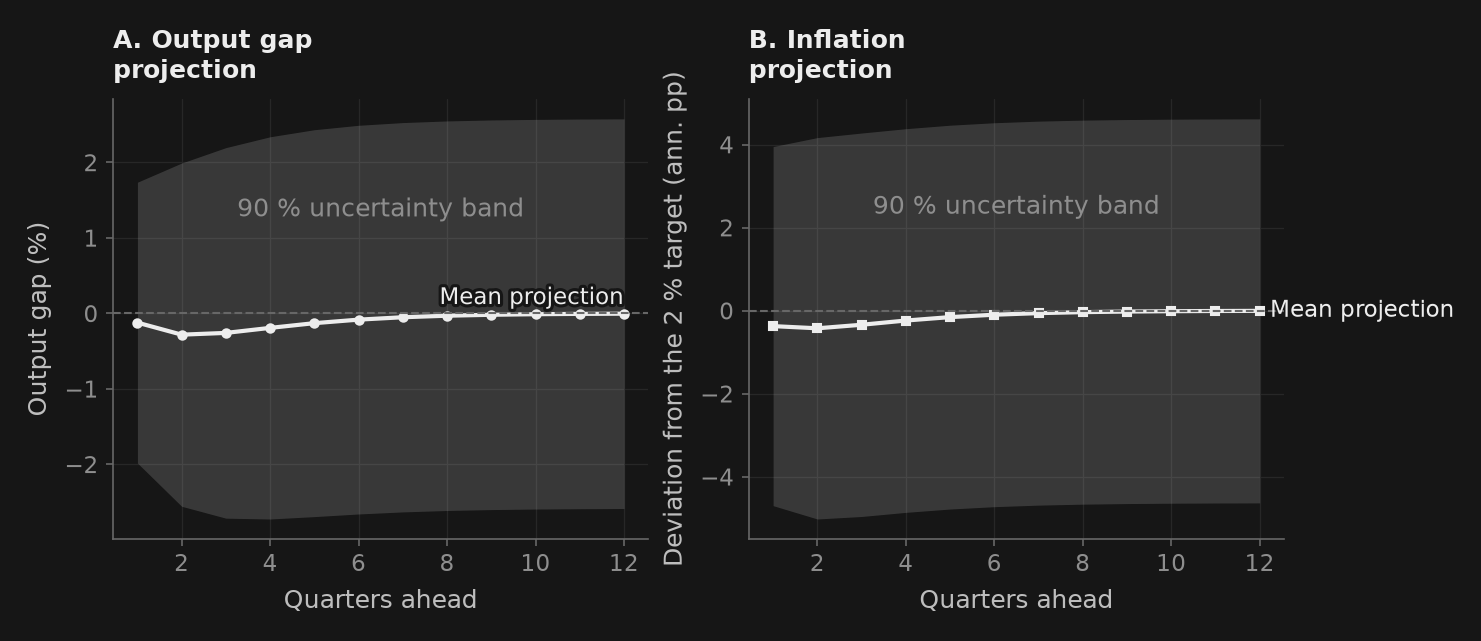

DYNAMIC DSGE FORECAST SUMMARY (H=12 Quarters Ahead)
Quarter Ahead  Output Gap Mean (%) Output Gap 90% CI  Inflation Mean (% ann) Inflation 90% CI
          h=1            -0.121805   [-1.98%, 1.74%]               -0.370964  [-4.69%, 3.95%]
          h=2            -0.281339   [-2.56%, 1.99%]               -0.423230  [-5.02%, 4.17%]
          h=3            -0.258043   [-2.71%, 2.20%]               -0.338206  [-4.96%, 4.28%]
          h=4            -0.191518   [-2.72%, 2.34%]               -0.236507  [-4.86%, 4.38%]
          h=5            -0.129036   [-2.69%, 2.43%]               -0.154144  [-4.78%, 4.47%]
          h=6            -0.082237   [-2.66%, 2.49%]               -0.096182  [-4.72%, 4.53%]
          h=7            -0.050553   [-2.63%, 2.53%]               -0.058266  [-4.68%, 4.57%]
          h=8            -0.030300   [-2.61%, 2.55%]               -0.034551  [-4.66%, 4.59%]
          h=9            -0.017825   [-2.60%, 2.56%]               -0.020160  [-4.64%, 4.60%]
        

In [13]:
# ==============================================================================
# Model-Consistent Dynamic DSGE Forecasting & Fan Charts
# ==============================================================================
# Dynamic forecast conditioned on terminal historical state
fc_nk = m_nk.forecast(horizon=12, data=df_post_covid, varobs=["y_gap", "pi", "i"], ci=0.90)

# Rescale forecast objects to standard macroeconomic presentation units
h_vec = np.arange(1, 13)
pi_mean_ann = fc_nk.mean["pi"].values * 400.0
pi_low_ann  = fc_nk.lower["pi"].values * 400.0
pi_upp_ann  = fc_nk.upper["pi"].values * 400.0

ygap_mean_pct = fc_nk.mean["y_gap"].values * 100.0
ygap_low_pct  = fc_nk.lower["y_gap"].values * 100.0
ygap_upp_pct  = fc_nk.upper["y_gap"].values * 100.0

fig, (ax_ygap, ax_pi) = _nbstyle.figura(1, 2)

# Panel 1: Output Gap Projection
ax_ygap.plot(h_vec, ygap_mean_pct, **_nbstyle.S1, marker="o", markersize=4, label="Mean projection")
ax_ygap.fill_between(h_vec, ygap_low_pct, ygap_upp_pct, color=_nbstyle.BANDA, lw=0)
ax_ygap.axhline(0, color=_nbstyle.SPINE, ls="--", lw=1.0)
ax_ygap.annotate("90 % uncertainty band", xy=(6.5, 0.55 * ygap_upp_pct[5]),
                 ha="center", va="center", color=_nbstyle.NOTA)
ax_ygap.set_title("A. Output gap\nprojection")
ax_ygap.set_xlabel("Quarters ahead")
ax_ygap.set_ylabel("Output gap (%)")
_nbstyle.etiquetar(ax_ygap, donde="fin")

# Panel 2: Inflation Projection
ax_pi.plot(h_vec, pi_mean_ann, **_nbstyle.S1, marker="s", markersize=4, label="Mean projection")
ax_pi.fill_between(h_vec, pi_low_ann, pi_upp_ann, color=_nbstyle.BANDA, lw=0)
ax_pi.axhline(0, color=_nbstyle.SPINE, ls="--", lw=1.0)
ax_pi.annotate("90 % uncertainty band", xy=(6.5, 0.55 * pi_upp_ann[5]),
               ha="center", va="center", color=_nbstyle.NOTA)
ax_pi.set_title("B. Inflation\nprojection")
ax_pi.set_xlabel("Quarters ahead")
ax_pi.set_ylabel("Deviation from the 2 % target (ann. pp)")
_nbstyle.etiquetar(ax_pi, donde="fin")

plt.show()

print("=" * 76)
print("DYNAMIC DSGE FORECAST SUMMARY (H=12 Quarters Ahead)")
print("=" * 76)
fc_summary_df = pd.DataFrame({
    "Quarter Ahead": [f"h={h}" for h in h_vec],
    "Output Gap Mean (%)": ygap_mean_pct,
    "Output Gap 90% CI": [f"[{l:.2f}%, {u:.2f}%]" for l, u in zip(ygap_low_pct, ygap_upp_pct)],
    "Inflation Mean (% ann)": pi_mean_ann,
    "Inflation 90% CI": [f"[{l:.2f}%, {u:.2f}%]" for l, u in zip(pi_low_ann, pi_upp_ann)],
})
print(fc_summary_df.to_string(index=False))
print("=" * 76)

# Verification Assertions
assert (fc_nk.lower["pi"] < fc_nk.mean["pi"]).all(), "Lower inflation band must lie below mean path."
assert (fc_nk.upper["pi"] > fc_nk.mean["pi"]).all(), "Upper inflation band must lie above mean path."
assert (fc_nk.lower["y_gap"] < fc_nk.mean["y_gap"]).all(), "Lower output gap band must lie below mean path."
assert (fc_nk.upper["y_gap"] > fc_nk.mean["y_gap"]).all(), "Upper output gap band must lie above mean path."
assert abs(fc_nk.mean.iloc[-1]["pi"]) < abs(fc_nk.mean.iloc[0]["pi"]), "Inflation must converge toward target over forecast horizon."
print("\nDynamic DSGE forward projection assertions successfully passed!")


## Non-Linear DSGE Simulation: Fair-Taylor (1983) Extended Path

Standard perturbation methods linearize equilibrium conditions around the deterministic steady state. While computationally instantaneous, first-order approximations impose **local certainty equivalence** and constant Jacobians. When macroeconomic shocks are large—such as the post-COVID inflation spike—or when the economy encounters **asymmetric policy rules and occasionally binding constraints** (such as policy rate floors), linear approximations can generate significant bias or fail to respect structural boundaries.

The **Extended Path method** (Fair & Taylor 1983), implemented natively in `puremacro.dsge.extended_path`, simulates non-linear dynamic models without perturbation and without the Bellman curse of dimensionality:
1. At each simulation period $t \in \{0, \dots, T-1\}$, the economy begins at historical predetermined state $y_{t-1}$ and receives contemporaneous structural innovation $u_t$.
2. Future stochastic innovations are replaced with their mathematical conditional expectation: $\mathbb{E}_t[u_{t+s}] = 0$ for all anticipation horizons $s \ge 1$.
3. The resulting deterministic boundary problem over horizon $T_H$ ($y_{t+T_H \mid t} = y_{ss}$) is formulated as a stacked non-linear system and solved via the sparse SuperLU Newton-Raphson boundary engine in `puremacro.dsge.solve_perfect_foresight`.
4. The contemporaneous state $y_t = y_{t \mid t}$ is recorded, historical state is advanced ($y_{t-1} \leftarrow y_t$), and date $t+1$ is warm-started.

### Key Properties & Invariants:
- **Linear Invariance**: For linear DSGE models, `extended_path` matches linear companion state-space simulation `m.simulate()` to machine precision ($< 10^{-10}$ max absolute deviation).
- **Mixed Complementarity Problems (MCP)**: Enforces inequality constraints (such as an asymmetric lower bound on the nominal interest rate $i_t \ge i_{\min}$) using semismooth complementarity solvers.

FAIR-TAYLOR EXTENDED PATH: LINEAR INVARIANCE VERIFICATION
Endogenous variable 'y_gap ': max |EP - Linear| = 3.82e-17
Endogenous variable 'pi    ': max |EP - Linear| = 1.91e-17
Endogenous variable 'i     ': max |EP - Linear| = 1.91e-17
Endogenous variable 'rn    ': max |EP - Linear| = 4.34e-19
Endogenous variable 'u     ': max |EP - Linear| = 1.73e-18


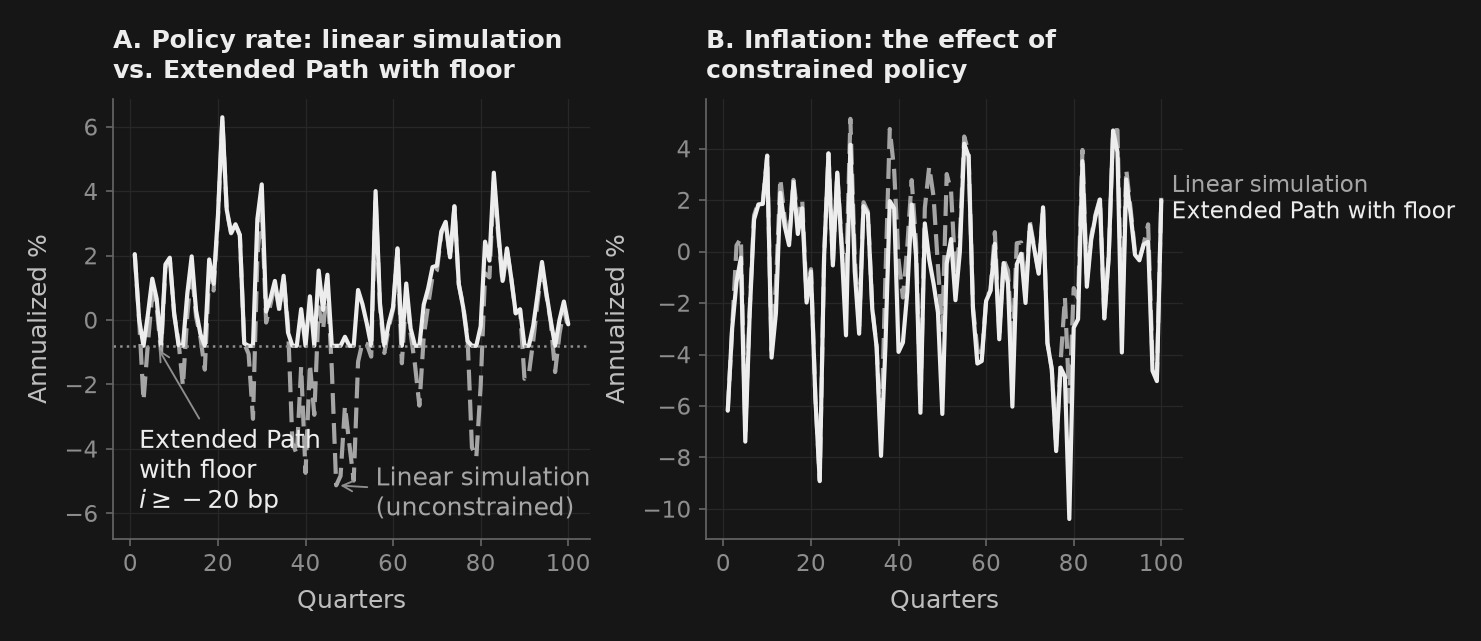


EXTENDED PATH SIMULATION RESULT (Fair-Taylor 1983)
Convergence status  : CONVERGED
Simulation periods  : 100
Forward horizon T_H : 80
Total iterations    : 574 (mean: 5.74, max: 9)
Residual norm       : 3.6178e-11
Terminal error      : 1.7491e-23
Endogenous vars (5) : y_gap, pi, i, rn, u
Structural shocks (3) : eps_i, eps_rn, eps_u
------------------------------------------------------------------------
TRAJECTORY SUMMARY (t=1..T):
           mean       std       min       max   initial  terminal
y_gap -0.008964  0.014403 -0.062057  0.018682 -0.001818  0.000875
pi    -0.002840  0.007919 -0.025976  0.011759 -0.015457  0.004959
i      0.001869  0.003755 -0.002000  0.015747  0.005119 -0.000331
rn    -0.001509  0.005582 -0.016586  0.011549  0.007357  0.000022
u     -0.000368  0.005273 -0.014183  0.011448 -0.008537  0.002896


In [14]:
# ==============================================================================
# Fair & Taylor (1983) Non-Linear Extended Path Stochastic Simulation
# ==============================================================================
from puremacro.dsge import extended_path

# 1. Stochastic simulation setup with identical structural innovations
sim_periods = 100
sim_horizon = 80
rng_seed = 20260909
sim_shocks = np.random.default_rng(rng_seed).normal(0.0, 0.005, size=(sim_periods, len(m_nk.shocks)))

# Run Fair-Taylor Extended Path Simulation
ep_nk = extended_path(
    m_nk,
    periods=sim_periods,
    horizon=sim_horizon,
    shocks=sim_shocks,
    tol=1e-8,
)

# Run standard linear companion simulation
sim_linear = m_nk.simulate(periods=sim_periods, shocks=sim_shocks)

# 2. Verify Exact Machine-Precision Equivalence for Linear Models
max_devs = {}
for var in m_nk.variables:
    dev = np.max(np.abs(ep_nk.path[var].values - sim_linear[var].values))
    max_devs[var] = dev

print("=" * 76)
print("FAIR-TAYLOR EXTENDED PATH: LINEAR INVARIANCE VERIFICATION")
print("=" * 76)
for var, dev in max_devs.items():
    print(f"Endogenous variable '{var:6s}': max |EP - Linear| = {dev:.2e}")
print("=" * 76)

assert ep_nk.converged is True, "Extended Path Newton-Raphson solver must converge."
assert all(d < 1e-10 for d in max_devs.values()), (
    "Extended Path must reproduce linear state-space simulation to machine precision."
)

# 3. Non-Linear Simulation with Policy Floor via Mixed Complementarity (MCP)
# Central bank enforces an asymmetric lower bound on the policy rate: i_t >= -0.0020 (-20 bps)
ep_mcp = extended_path(
    m_nk,
    periods=sim_periods,
    horizon=sim_horizon,
    shocks=sim_shocks,
    mcp=True,
    mcp_bounds={"i": (-0.002, None)},
    tol=1e-8,
)

assert ep_mcp.converged is True, "Extended Path with MCP bounds must converge."
assert (ep_mcp.path["i"] >= -0.002 - 1e-10).all(), "Policy floor must be strictly respected."

# 4. Comparative Trajectory Visualization
fig, (ax_ep_i, ax_ep_pi) = _nbstyle.figura(1, 2)

t_axis = np.arange(1, sim_periods + 1)

# Nominal Policy Rate Comparison
ax_ep_i.plot(t_axis, sim_linear["i"] * 400, **_nbstyle.S2, label="Linear simulation\n(unconstrained)")
ax_ep_i.plot(t_axis, ep_mcp.path["i"] * 400, **_nbstyle.S1, label="Extended Path\nwith floor")
ax_ep_i.axhline(-0.002 * 400, color=_nbstyle.NOTA, ls=":", lw=1.2)
ax_ep_i.set_title("A. Policy rate: linear simulation\nvs. Extended Path with floor")
ax_ep_i.set_xlabel("Quarters")
ax_ep_i.set_ylabel("Annualized %")
# The two series part only where the floor bites: each is named there, from the free space
# below its path (the linear one at its deepest trough, the other just above the floor)
ax_ep_i.set_ylim(bottom=-6.8)
lin_i, mcp_i = ax_ep_i.get_lines()[:2]
t_min = int(np.argmin(sim_linear["i"].values)) + 1
ax_ep_i.annotate(lin_i.get_label(), xy=(t_min, float(sim_linear["i"].min() * 400)),
                 xytext=(t_min + 9, -5.4), ha="left", va="center", color=lin_i.get_color(),
                 arrowprops=_nbstyle.FLECHA)
ax_ep_i.annotate(mcp_i.get_label() + "\n$i \\geq -20$ bp", xy=(6.0, -0.002 * 400), xytext=(2.0, -4.7),
                 ha="left", va="center", color=mcp_i.get_color(), arrowprops=_nbstyle.FLECHA)

# Inflation Trajectory Comparison
ax_ep_pi.plot(t_axis, sim_linear["pi"] * 400, **_nbstyle.S2, label="Linear simulation")
ax_ep_pi.plot(t_axis, ep_mcp.path["pi"] * 400, **_nbstyle.S1, label="Extended Path with floor")
ax_ep_pi.set_title("B. Inflation: the effect of\nconstrained policy")
ax_ep_pi.set_xlabel("Quarters")
ax_ep_pi.set_ylabel("Annualized %")
_nbstyle.etiquetar(ax_ep_pi, donde="fin")

plt.show()

# 5. Publication Summary Report
print("\n" + ep_mcp.summary())
